# Series - Vias de Ingreso 
Se construye una serie mensual para cada vía de ingreso:
- Aérea
- Terrestre
- Marítima

En total se obtendrán tres series.

## Librerías y Config

In [4]:
from pathlib import Path
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing
)

from sklearn.metrics import mean_absolute_error, mean_squared_error


from prophet import Prophet


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.figsize": (13, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

## Carga y análisis de datos

In [5]:
RUTAS_CANDIDATAS = [
    Path("../data/raw/Base_Migracion_2009-2026jun.xlsx"),
    Path("L01_series_tiempo/data/raw/Base_Migracion_2009-2026jun.xlsx"),
    Path("data/raw/Base_Migracion_2009-2026jun.xlsx"),
    Path("Base_Migracion_2009-2026jun.xlsx")
]

RUTA_DATOS = next(
    (ruta for ruta in RUTAS_CANDIDATAS if ruta.exists()),
    None
)

if RUTA_DATOS is None:
    rutas_revisadas = "\n".join(
        str(ruta.resolve())
        for ruta in RUTAS_CANDIDATAS
    )
    raise FileNotFoundError(
        "No se encontró el archivo Base_Migracion_2009-2026jun.xlsx. "
        f"Rutas revisadas:\n{rutas_revisadas}"
    )

archivo_excel = pd.ExcelFile(RUTA_DATOS)

print("Archivo encontrado en:", RUTA_DATOS.resolve())
print("Hojas disponibles:")
print(archivo_excel.sheet_names)

datos_raw = pd.read_excel(
    RUTA_DATOS,
    sheet_name="Datos"
)

notas = pd.read_excel(
    RUTA_DATOS,
    sheet_name="Notas"
)

print("Dimensiones de la hoja Datos:", datos_raw.shape)
print("Dimensiones de la hoja Notas:", notas.shape)

Archivo encontrado en: C:\Users\viank\OneDrive\Desktop\S1_2026\Data-Science\L01_series_tiempo\data\raw\Base_Migracion_2009-2026jun.xlsx
Hojas disponibles:
['Datos', 'Notas']


Dimensiones de la hoja Datos: (161036, 13)
Dimensiones de la hoja Notas: (9, 2)


In [6]:
display(datos_raw.head())
datos_raw.info()

display(
    pd.DataFrame({
        "Columnas": datos_raw.columns,
        "Tipos de datos": datos_raw.dtypes.astype(str).values,
        "Valores nulos": datos_raw.isnull().sum().values
    })
)

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.00
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.00
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.00
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.00


<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


,Columnas,Tipos de datos,Valores nulos
0,Año,int64,0
1,Mes cod,int64,0
2,Mes,str,0
3,Vía,str,0
4,Frontera,str,0
5,País,str,0
6,Región,str,0
7,Región dos,str,0
8,Regiones OMT,str,0
9,MCEO,str,0


### análisis de datos

Cada fila de la base representa una combinación mensual de características
migratorias. La variable `Viajero` contiene la cantidad asociada con esa
combinación. Para construir las series no se cuentan filas: se suma `Viajero`
por mes y vía de ingreso.

## Limpieza y preparación de datos

In [7]:
# limpieza y prepara los datos
datos = datos_raw.copy()
datos.columns = datos.columns.astype(str).str.strip()

# validar columnas necesarias
columnas_necesarias = [
    "Año",
    "Mes cod",
    "Mes",
    "Vía",
    "Tipo de Viajero",
    "Viajero"
]

columnas_faltantes = [
    columna
    for columna in columnas_necesarias
    if columna not in datos.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias en los datos: {columnas_faltantes}"
    )

print("Columnas necesarias presentes en los datos.")

Columnas necesarias presentes en los datos.


In [8]:
# Convertir variables
datos["Año"] = pd.to_numeric(
    datos["Año"],
    errors="coerce"
)

datos["Mes cod"] = pd.to_numeric(
    datos["Mes cod"],
    errors="coerce"
)

datos["Viajero"] = pd.to_numeric(
    datos["Viajero"],
    errors="coerce"
)

# Limpiar variables de texto
columnas_texto = [
    "Mes",
    "Vía",
    "Tipo de Viajero"
]

for columna in columnas_texto:
    datos[columna] = (
        datos[columna]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Estandarizar categorías
datos["Vía"] = datos["Vía"].str.title()
datos["Tipo de Viajero"] = datos["Tipo de Viajero"].str.title()

datos["Vía"] = datos["Vía"].replace({
    "Aerea": "Aérea",
    "Maritima": "Marítima"
})

# Crear fecha mensual
datos["Fecha"] = pd.to_datetime(
    dict(
        year=datos["Año"],
        month=datos["Mes cod"],
        day=1
    ),
    errors="coerce"
)

datos = datos.sort_values("Fecha").reset_index(drop=True)

# Revisar resultado
display(
    datos[
        [
            "Año",
            "Mes cod",
            "Mes",
            "Fecha",
            "Vía",
            "Tipo de Viajero",
            "Viajero"
        ]
    ].head()
)

,Año,Mes cod,Mes,Fecha,Vía,Tipo de Viajero,Viajero
0,2009,1,Ene,2009-01-01,Aérea,Turista,1.00
1,2009,1,Ene,2009-01-01,Terrestre,Turista,11.00
2,2009,1,Ene,2009-01-01,Terrestre,Turista,7.00
3,2009,1,Ene,2009-01-01,Terrestre,Turista,2.00
4,2009,1,Ene,2009-01-01,Terrestre,Turista,1.00


### Calidad de los datos

In [9]:
faltantes = (
    datos.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Cantidad_faltantes")
)

faltantes["Porcentaje"] = (
    faltantes["Cantidad_faltantes"]
    / len(datos)
    * 100
)

display(faltantes)

print("Fechas inválidas:", datos["Fecha"].isna().sum())
print("Duplicados exactos:", datos.duplicated().sum())
print("Valores negativos:", (datos["Viajero"] < 0).sum())
print("Valores iguales a cero:", (datos["Viajero"] == 0).sum())

,Cantidad_faltantes,Porcentaje
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


Fechas inválidas: 0
Duplicados exactos: 0
Valores negativos: 0
Valores iguales a cero: 54


In [10]:
viajeros_validos = datos["Viajero"].dropna()

q1 = viajeros_validos.quantile(0.25)
q3 = viajeros_validos.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos = datos[
    (datos["Viajero"] < limite_inferior)
    | (datos["Viajero"] > limite_superior)
]

print("Valores atípicos según IQR:", len(atipicos))
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Valores atípicos según IQR: 26390
Límite inferior: -53.3375
Límite superior: 94.22916666666666


Los valores atípicos no se eliminan automáticamente. Una observación elevada
puede corresponder a un país, frontera o mes con un flujo legítimamente alto.
La evaluación principal se hará después sobre los totales mensuales.

## Construcción de las series mensuales

Inicialmente se aplicó el filtro `Turista + Excursionista` a las tres vías,
siguiendo la instrucción general del laboratorio. Al revisar los resultados se
encontró que la serie marítima quedaba sin observaciones desde 2017.

Antes de sustituir valores faltantes por cero, se revisa la base completa para
determinar si realmente dejaron de existir ingresos marítimos o si cambió su
clasificación.

In [11]:
TIPOS_COMPARABLES = [
    "Turista",
    "Excursionista"
]

VIAS = [
    "Aérea",
    "Terrestre",
    "Marítima"
]

vias_despues_2016 = (
    datos.loc[
        datos["Fecha"] >= "2017-01-01",
        "Vía"
    ]
    .value_counts(dropna=False)
)

print("Vías registradas desde 2017:")
display(vias_despues_2016)

print("Nombres relacionados con la vía marítima:")

for valor in sorted(datos["Vía"].dropna().astype(str).unique()):
    if "mar" in valor.lower():
        print(repr(valor))

Vías registradas desde 2017:


Vía
Terrestre    58102
Aérea        10303
Marítima      2008
Name: count, dtype: Int64

Nombres relacionados con la vía marítima:
'Marítima'


In [12]:
# Todos los registros marítimos sin filtrar el tipo de viajero
maritima_todos = datos[
    datos["Vía"].eq("Marítima")
    & datos["Fecha"].notna()
    & datos["Viajero"].notna()
].copy()

maritima_todos["Año_revision"] = (
    maritima_todos["Fecha"].dt.year
)

# Registros marítimos bajo el filtro general
maritima_comparable = maritima_todos[
    maritima_todos["Tipo de Viajero"].isin(
        TIPOS_COMPARABLES
    )
].copy()

resumen_todos = (
    maritima_todos
    .groupby("Año_revision")
    .agg(
        Filas_todos=("Viajero", "size"),
        Meses_todos=("Fecha", "nunique"),
        Total_todos=("Viajero", "sum")
    )
)

resumen_comparable = (
    maritima_comparable
    .groupby("Año_revision")
    .agg(
        Filas_comparables=("Viajero", "size"),
        Meses_comparables=("Fecha", "nunique"),
        Total_comparable=("Viajero", "sum")
    )
)

comparacion_maritima = pd.concat(
    [
        resumen_todos,
        resumen_comparable
    ],
    axis=1
)

display(comparacion_maritima)

,Filas_todos,Meses_todos,Total_todos,Filas_comparables,Meses_comparables,Total_comparable
Año_revision,,,,,,
2009,973,12,"93,704.00",957.00,12.00,"12,358.00"
2010,980,12,"85,163.00",964.00,12.00,"12,675.00"
2011,981,12,"85,319.00",963.00,12.00,"12,969.00"
2012,1013,12,"86,128.00",997.00,12.00,"13,282.00"
2013,1058,12,"84,932.00","1,041.00",12.00,"13,242.00"
2014,1067,12,"83,857.00","1,052.00",12.00,"13,256.00"
2015,1055,12,"89,076.00","1,039.00",12.00,"11,881.00"
2016,1029,12,"114,290.00","1,010.00",12.00,"10,578.00"
2017,18,11,"129,063.00",NaN,NaN,NaN


In [13]:
maritima_por_tipo = (
    maritima_todos
    .groupby("Tipo de Viajero")
    .agg(
        Filas=("Viajero", "size"),
        Total=("Viajero", "sum"),
        Primera_fecha=("Fecha", "min"),
        Última_fecha=("Fecha", "max")
    )
    .sort_values(
        "Total",
        ascending=False
    )
)

print("Registros marítimos por tipo de viajero:")
display(maritima_por_tipo)

Registros marítimos por tipo de viajero:


,Filas,Total,Primera_fecha,Última_fecha
Tipo de Viajero,,,,
Cruceristas,204,"1,104,402.00",2009-01-01,2022-12-01
Turista,8023,"100,241.00",2009-01-01,2016-12-01
Viajero,1937,"24,139.00",2023-01-01,2026-06-01


### Cambio aplicado en la serie marítima

La revisión muestra que desde 2017 **sí existen registros marítimos**, pero ya
no aparecen bajo `Turista` o `Excursionista`. Los ceros observados inicialmente
no eran ceros reales: eran meses sin observaciones después de aplicar ese
filtro.

Por ello se utilizará el siguiente criterio:

- **Aérea:** Turista + Excursionista.
- **Terrestre:** Turista + Excursionista.
- **Marítima:** todos los tipos de viajero.

Este criterio permite conservar el flujo marítimo registrado. Sin embargo, la
serie marítima tiene cambios de clasificación y desagregación, por lo que se
analiza como una serie independiente y sus niveles no se comparan directamente
con los de Aérea y Terrestre sin mencionar esta limitación.

In [14]:
# Aérea y Terrestre: Turista + Excursionista
datos_aerea_terrestre = datos[
    datos["Tipo de Viajero"].isin(
        TIPOS_COMPARABLES
    )
    & datos["Vía"].isin(
        ["Aérea", "Terrestre"]
    )
    & datos["Fecha"].notna()
    & datos["Viajero"].notna()
].copy()

series_aerea_terrestre = (
    datos_aerea_terrestre
    .groupby(
        ["Fecha", "Vía"]
    )["Viajero"]
    .sum(min_count=1)
    .unstack("Vía")
    .sort_index()
)

# Marítima: todos los tipos de viajero
serie_maritima = (
    datos[
        datos["Vía"].eq("Marítima")
        & datos["Fecha"].notna()
        & datos["Viajero"].notna()
    ]
    .groupby("Fecha")["Viajero"]
    .sum(min_count=1)
    .sort_index()
)

# Calendario mensual común
calendario_completo = pd.date_range(
    start=datos["Fecha"].min(),
    end=datos["Fecha"].max(),
    freq="MS"
)

series_vias_sin_completar = pd.DataFrame(
    index=calendario_completo
)

series_vias_sin_completar.index.name = "Fecha"

series_vias_sin_completar["Aérea"] = (
    series_aerea_terrestre["Aérea"]
    .reindex(calendario_completo)
)

series_vias_sin_completar["Terrestre"] = (
    series_aerea_terrestre["Terrestre"]
    .reindex(calendario_completo)
)

series_vias_sin_completar["Marítima"] = (
    serie_maritima
    .reindex(calendario_completo)
)

print("Meses sin registro antes de completar:")
display(
    series_vias_sin_completar
    .isna()
    .sum()
    .to_frame("Meses_sin_registro")
)

Meses sin registro antes de completar:


,Meses_sin_registro
Aérea,0
Terrestre,0
Marítima,27


Después de incluir correctamente los registros de cada vía, los meses que no
tienen ninguna fila se representan como cero movimientos registrados. Esto se
hace **después** de corregir la construcción marítima, no antes.

In [15]:
series_vias = (
    series_vias_sin_completar
    .fillna(0)
    .astype(float)
    .asfreq("MS")
)

display(series_vias.head())
display(series_vias.tail())

print("Valores faltantes finales:")
display(
    series_vias.isna()
    .sum()
    .to_frame("Cantidad")
)

print("Meses con cero:")
display(
    (series_vias == 0)
    .sum()
    .to_frame("Cantidad")
)

,Aérea,Terrestre,Marítima
Fecha,,,
2009-01-01,"81,693.00","67,442.03","13,379.00"
2009-02-01,"70,099.00","56,266.69","11,674.00"
2009-03-01,"84,494.00","73,111.67","11,522.00"
2009-04-01,"80,618.00","89,897.47","9,290.00"
2009-05-01,"64,621.00","58,898.52","6,517.00"


,Aérea,Terrestre,Marítima
Fecha,,,
2026-02-01,"106,821.00","130,023.11",758.00
2026-03-01,"127,540.00","163,620.37",672.00
2026-04-01,"102,029.00","158,922.05",720.00
2026-05-01,"95,804.00","145,508.30",603.00
2026-06-01,"98,211.00","147,476.58",576.00


Valores faltantes finales:


,Cantidad
Aérea,0
Terrestre,0
Marítima,0


Meses con cero:


,Cantidad
Aérea,0
Terrestre,0
Marítima,27


In [16]:
def resumen_serie(
    serie: pd.Series,
    nombre: str
) -> dict:
    return {
        "Serie": nombre,
        "Inicio": serie.index.min(),
        "Fin": serie.index.max(),
        "Frecuencia": pd.infer_freq(serie.index),
        "Observaciones": len(serie),
        "Meses_con_cero": int((serie == 0).sum()),
        "Total_acumulado": serie.sum(),
        "Media_mensual": serie.mean(),
        "Mediana": serie.median(),
        "Desviación_estándar": serie.std(),
        "Mínimo": serie.min(),
        "Máximo": serie.max()
    }


resumen_series = pd.DataFrame([
    resumen_serie(
        series_vias[via],
        via
    )
    for via in VIAS
])

display(resumen_series)

,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses_con_cero,Total_acumulado,Media_mensual,Mediana,Desviación_estándar,Mínimo,Máximo
0,Aérea,2009-01-01,2026-06-01,MS,210,0,"19,019,418.55","90,568.66","90,941.00","27,855.30",489.00,"158,463.00"
1,Terrestre,2009-01-01,2026-06-01,MS,210,0,"27,592,253.33","131,391.68","134,582.88","60,815.99","5,240.00","291,272.07"
2,Marítima,2009-01-01,2026-06-01,MS,210,27,"1,228,782.00","5,851.34","2,010.50","6,708.80",0.00,"29,506.00"


In [17]:
assert list(series_vias.columns) == VIAS
assert series_vias.index.is_monotonic_increasing
assert not series_vias.index.duplicated().any()
assert series_vias.isna().sum().sum() == 0
assert pd.infer_freq(series_vias.index) == "MS"

print(
    "Validación completada: "
    "las tres series tienen frecuencia mensual y no contienen valores faltantes."
)

Validación completada: las tres series tienen frecuencia mensual y no contienen valores faltantes.


## Análisis exploratorio de las vías

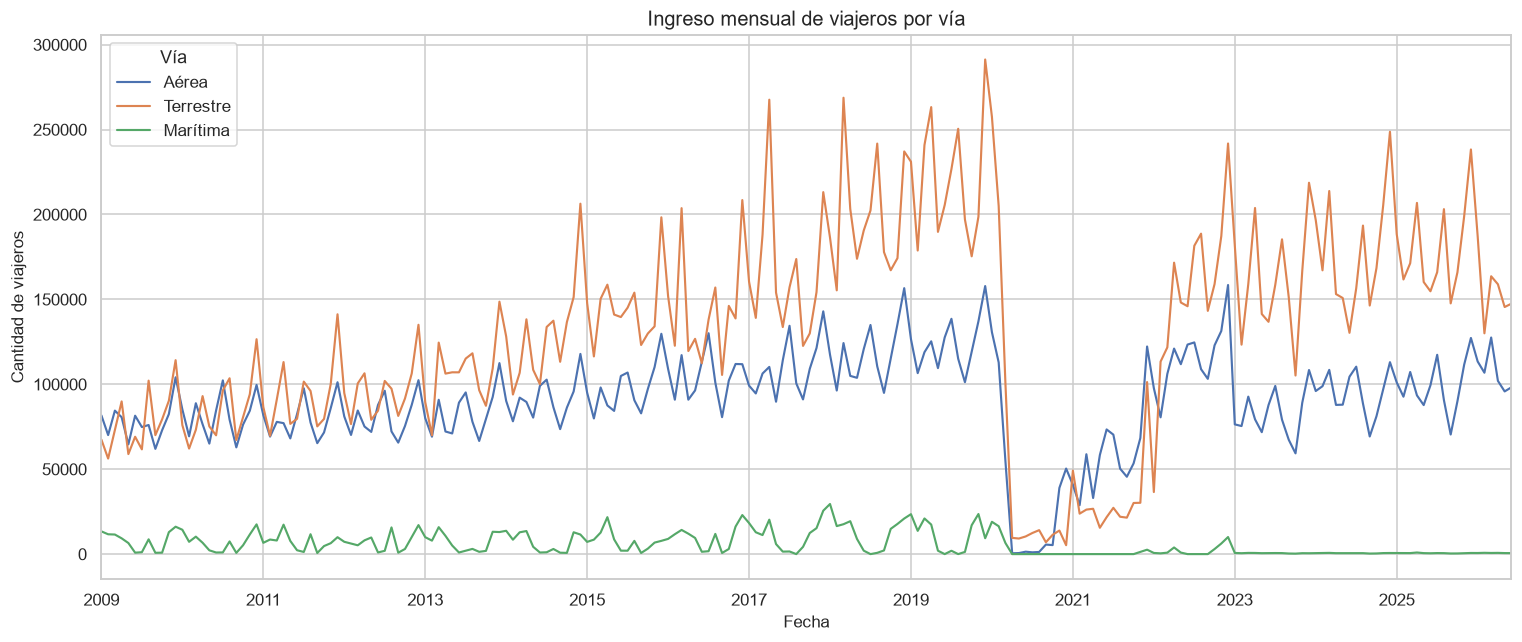

In [18]:
ax = series_vias.plot(
    figsize=(14, 6),
    linewidth=1.4
)

ax.set_title(
    "Ingreso mensual de viajeros por vía"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de viajeros")
ax.legend(title="Vía")

plt.tight_layout()
plt.show()

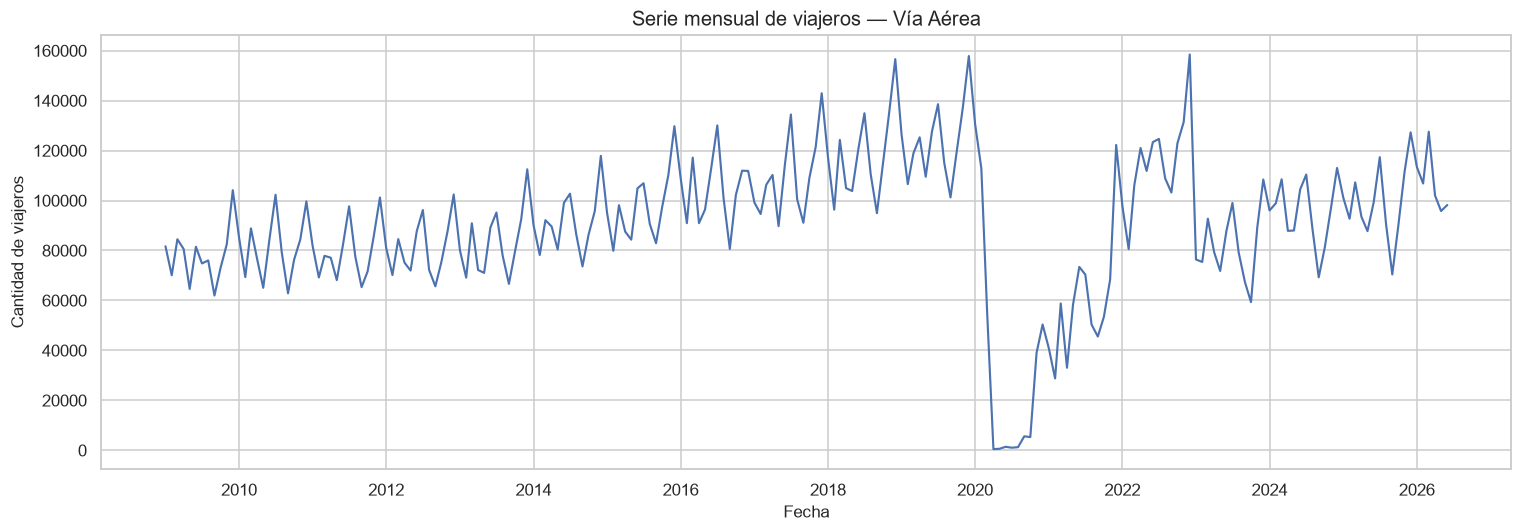

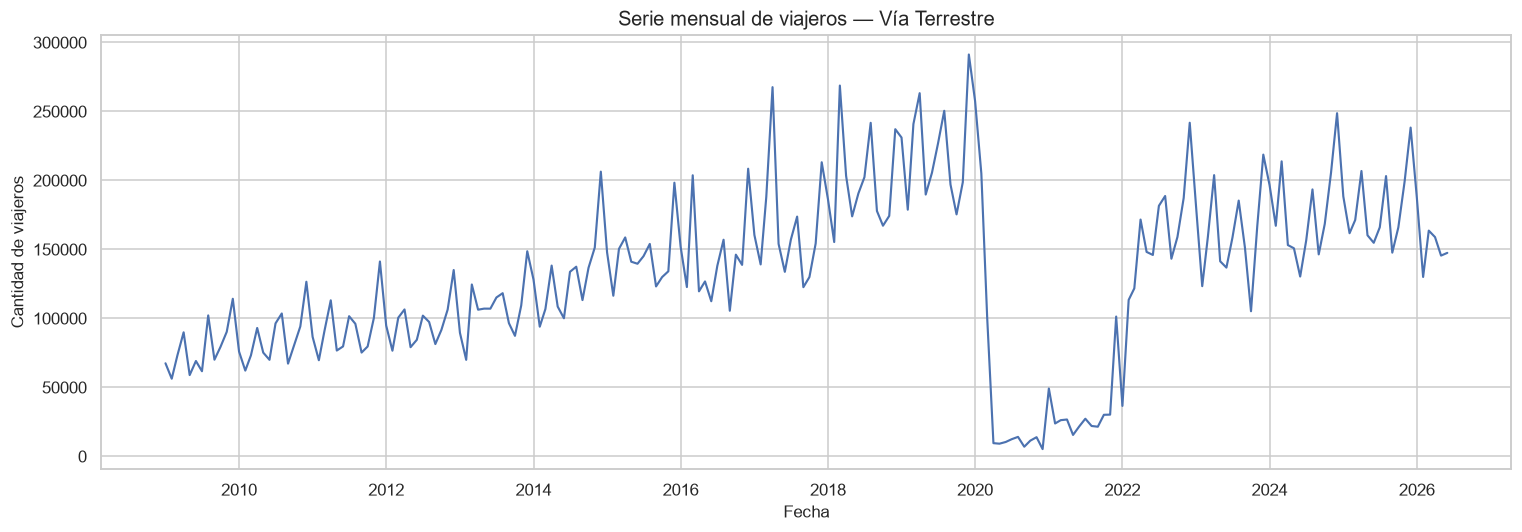

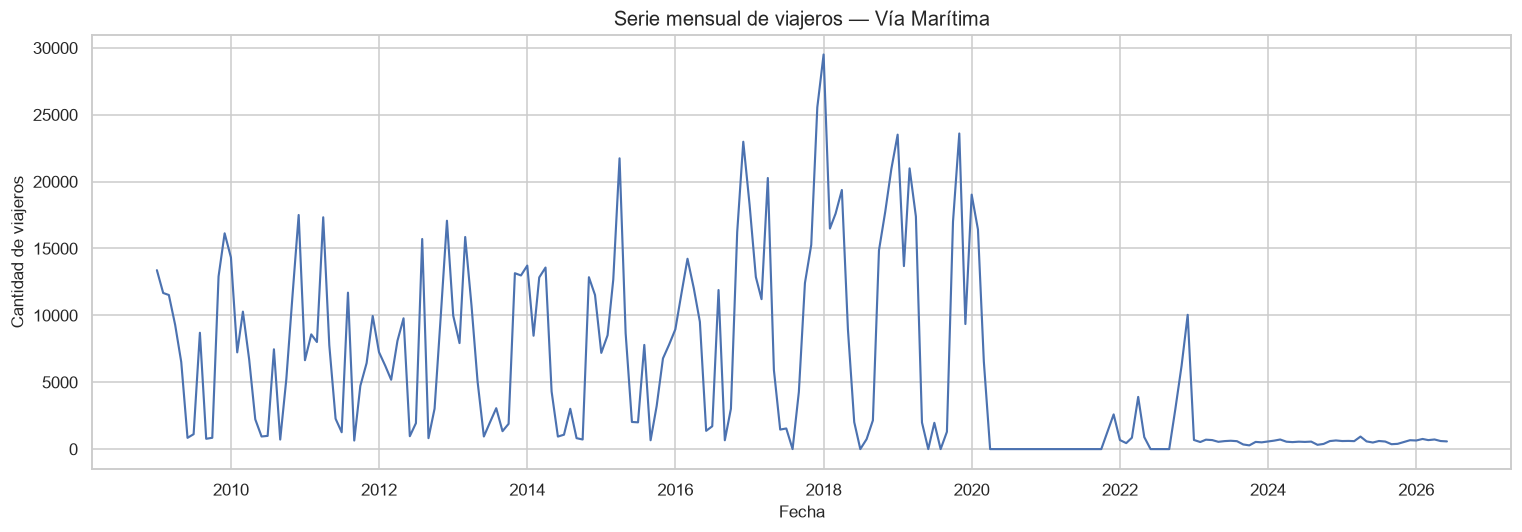

In [19]:
for via in VIAS:
    plt.figure(figsize=(14, 5))

    plt.plot(
        series_vias.index,
        series_vias[via],
        linewidth=1.4
    )

    plt.title(
        f"Serie mensual de viajeros — Vía {via}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")

    plt.tight_layout()
    plt.show()

### análisis de datos

Aérea y Terrestre se pueden comparar directamente porque utilizan el mismo
criterio de Turista + Excursionista. Marítima debe observarse por separado:
sus cambios alrededor de 2017 y 2023 podrían reflejar cambios de clasificación
o desagregación, además de cambios reales en el flujo.

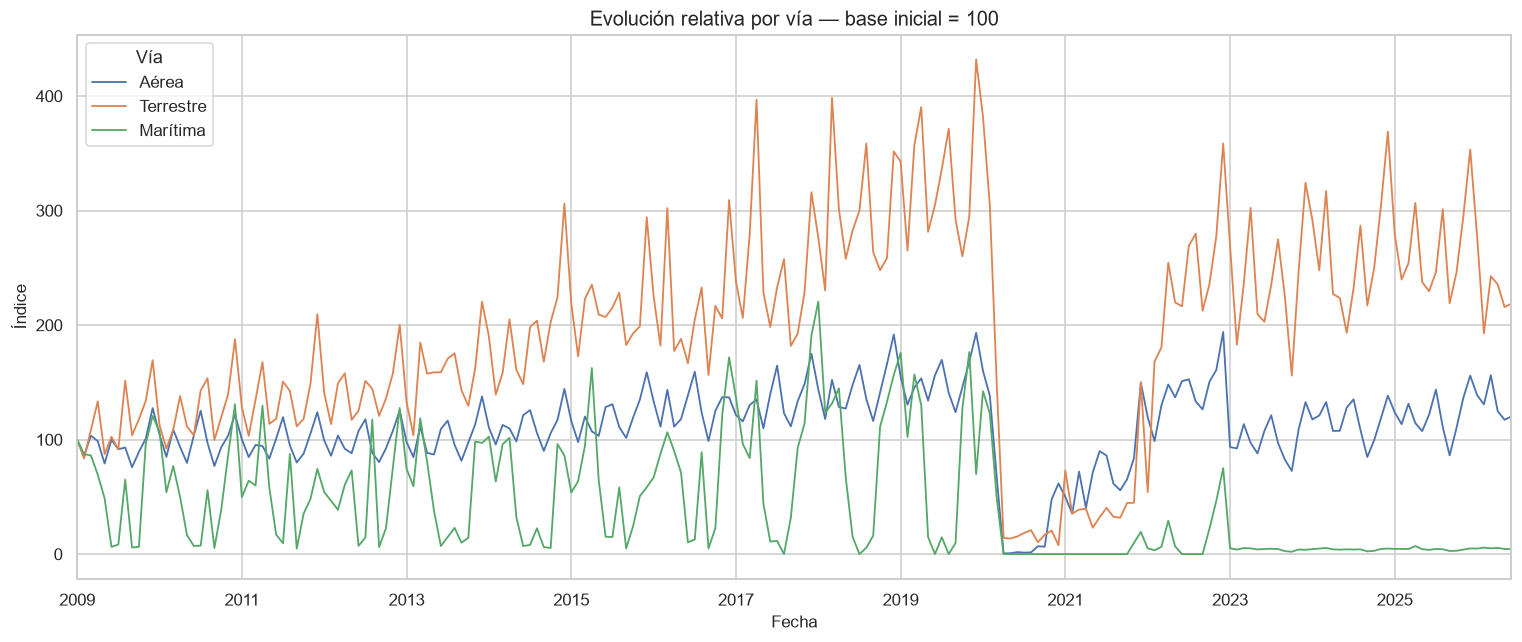

In [20]:
# Comparación relativa: cada serie inicia en 100.
# Este gráfico compara trayectorias, no volúmenes absolutos.
primer_valor_positivo = {}

for via in VIAS:
    valores_positivos = series_vias.loc[
        series_vias[via] > 0,
        via
    ]
    primer_valor_positivo[via] = (
        valores_positivos.iloc[0]
    )

series_normalizadas = pd.DataFrame({
    via: (
        series_vias[via]
        / primer_valor_positivo[via]
        * 100
    )
    for via in VIAS
})

ax = series_normalizadas.plot(
    figsize=(14, 6),
    linewidth=1.2
)

ax.set_title(
    "Evolución relativa por vía — base inicial = 100"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Índice")
ax.legend(title="Vía")

plt.tight_layout()
plt.show()

,Aérea,Terrestre,Marítima
Fecha,,,
2009,"935,379.00","932,445.85","93,704.00"
2010,"974,233.00","1,017,876.00","85,163.00"
2011,"955,964.00","1,110,781.60","85,319.00"
2012,"970,530.00","1,155,729.48","86,128.00"
2013,"996,787.00","1,279,673.75","84,932.00"
2014,"1,092,353.00","1,554,568.32","83,857.00"
2015,"1,167,412.00","1,738,593.04","89,076.00"
2016,"1,255,323.43","1,731,125.32","114,290.00"
2017,"1,313,790.00","1,993,861.29","129,063.00"


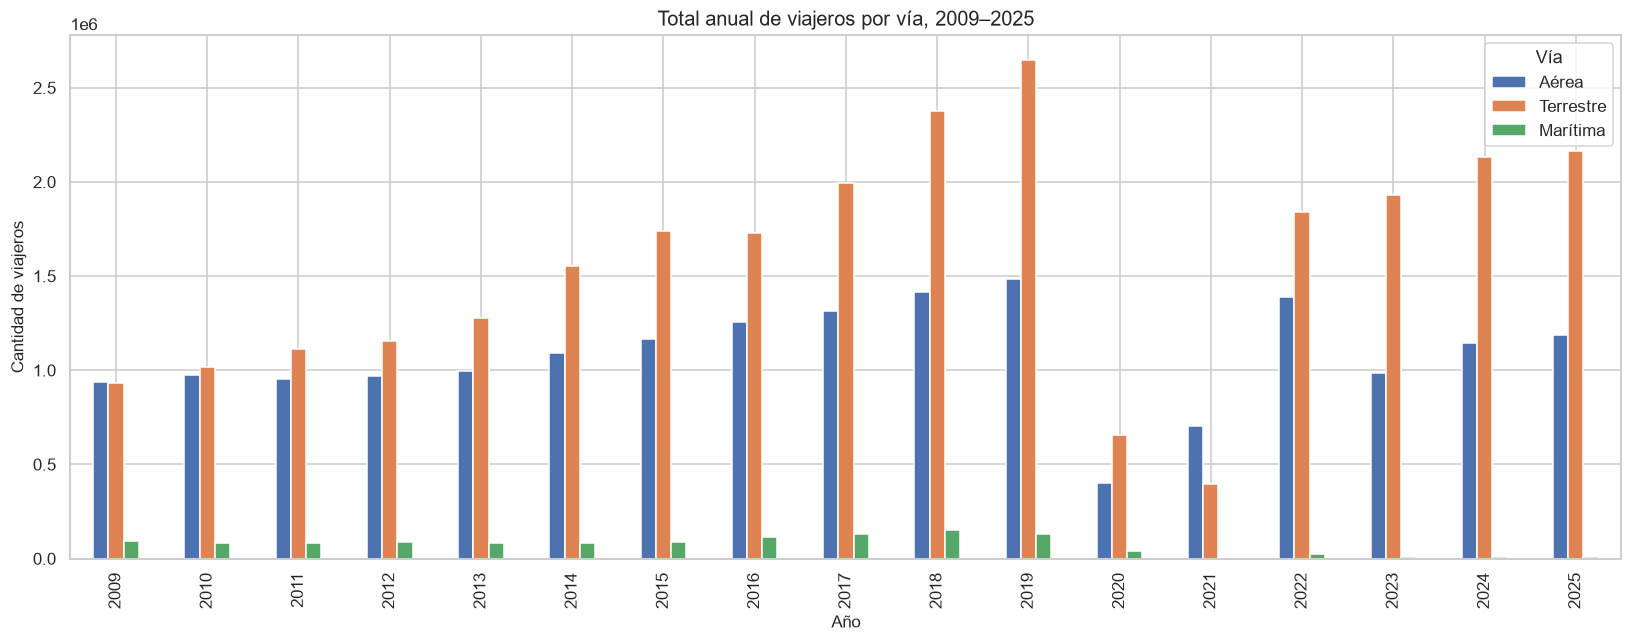

Total parcial enero-junio de 2026:


,Aérea,Terrestre,Marítima
Fecha,,,
2026,"643,840.00","932,779.48","3,973.00"


In [21]:
totales_anuales = (
    series_vias
    .resample("YS")
    .sum()
)

totales_anuales.index = (
    totales_anuales.index.year
)

display(totales_anuales)

# 2026 contiene únicamente enero-junio.
totales_anuales_completos = (
    totales_anuales.loc[
        totales_anuales.index <= 2025
    ]
)

ax = totales_anuales_completos.plot(
    kind="bar",
    figsize=(15, 6)
)

ax.set_title(
    "Total anual de viajeros por vía, 2009–2025"
)

ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de viajeros")
ax.legend(title="Vía")

plt.tight_layout()
plt.show()

print("Total parcial enero-junio de 2026:")
display(
    totales_anuales.loc[[2026]]
)

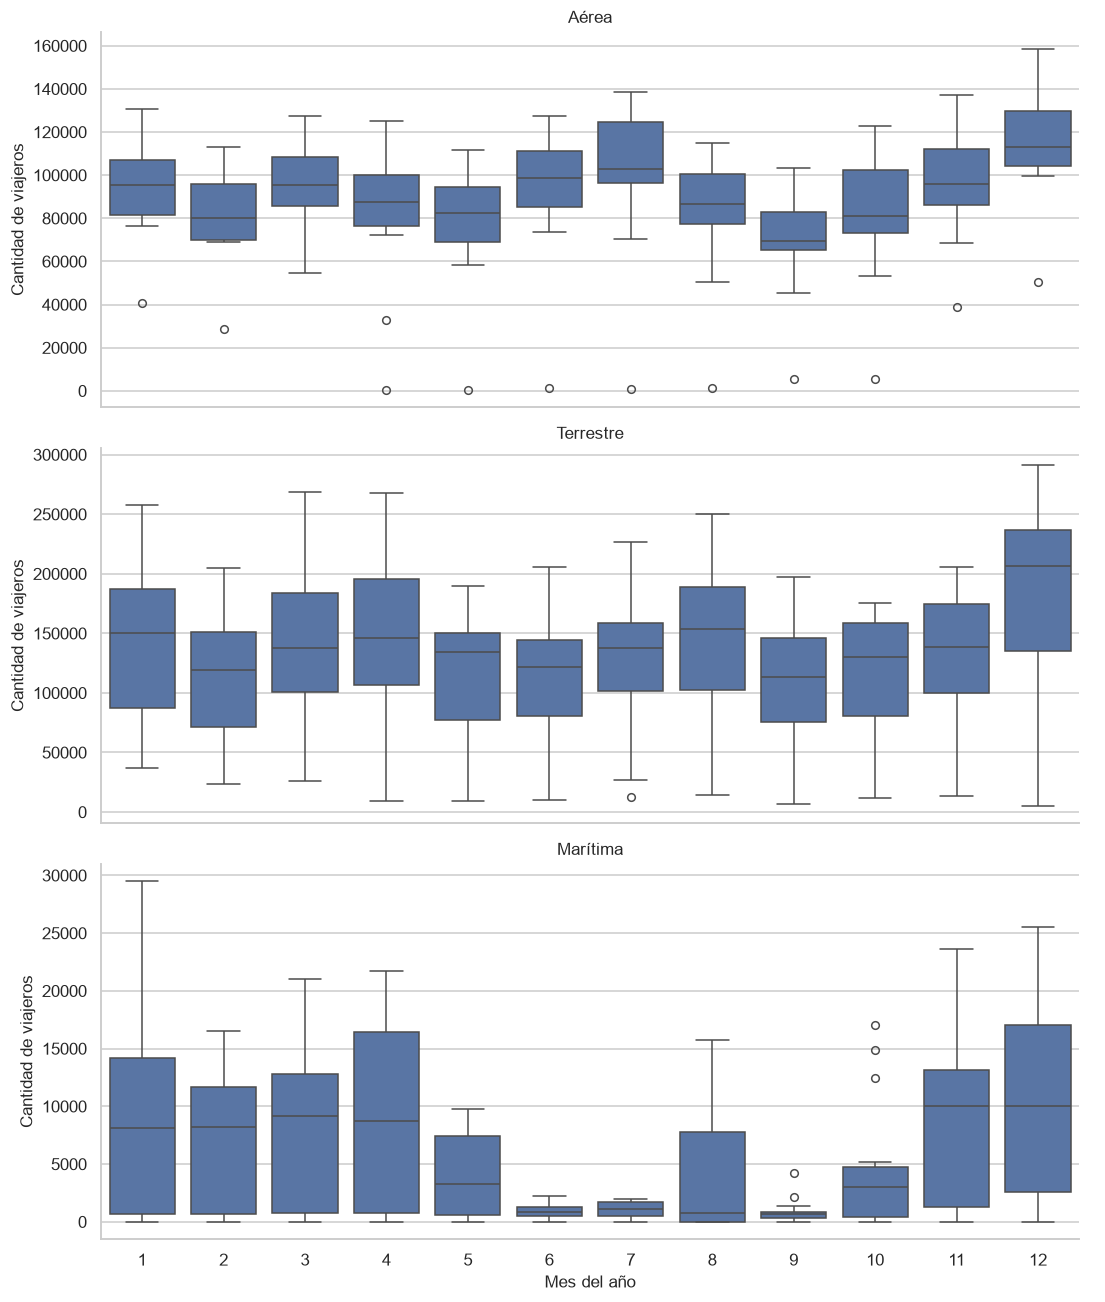

In [22]:
series_largas = (
    series_vias
    .reset_index()
    .melt(
        id_vars="Fecha",
        var_name="Vía",
        value_name="Viajeros"
    )
)

series_largas["Mes_numero"] = (
    series_largas["Fecha"].dt.month
)

g = sns.catplot(
    data=series_largas,
    x="Mes_numero",
    y="Viajeros",
    col="Vía",
    kind="box",
    col_wrap=1,
    height=4,
    aspect=2.5,
    sharey=False
)

g.set_axis_labels(
    "Mes del año",
    "Cantidad de viajeros"
)

g.set_titles("{col_name}")

plt.show()

Los boxplots permiten identificar meses que tienden a presentar valores altos o
bajos de manera repetida. Si esas diferencias se repiten anualmente, existe
evidencia visual de estacionalidad. Esta observación se confirmará después con
la descomposición STL y la función de autocorrelación.

In [23]:
anios_revision = [
    2019,
    2020,
    2021,
    2022,
    2023
]

comparacion_pandemia = (
    totales_anuales.loc[
        totales_anuales.index.isin(
            anios_revision
        )
    ]
    .copy()
)

display(comparacion_pandemia)

caida_2020 = (
    (
        totales_anuales.loc[2020]
        - totales_anuales.loc[2019]
    )
    / totales_anuales.loc[2019]
    * 100
)

display(
    caida_2020.to_frame(
        "Cambio_2020_vs_2019_%"
    )
)

,Aérea,Terrestre,Marítima
Fecha,,,
2019,"1,483,385.91","2,648,864.69","130,789.00"
2020,"403,524.93","656,245.51","41,992.00"
2021,"703,471.24","395,493.14","3,908.00"
2022,"1,390,275.00","1,839,053.60","26,030.00"
2023,"985,840.00","1,931,986.81","6,617.00"


,Cambio_2020_vs_2019_%
Aérea,-72.80
Terrestre,-75.23
Marítima,-67.89


El cambio porcentual entre 2019 y 2020 mide el impacto inicial de la pandemia.
En Marítima se interpreta con cautela debido al cambio metodológico documentado.

## División de los datos en entrenamiento y prueba

In [24]:
cantidad_total = len(series_vias)

cantidad_train = int(
    np.floor(
        cantidad_total * 0.70
    )
)

cantidad_test = (
    cantidad_total
    - cantidad_train
)

train_vias = (
    series_vias
    .iloc[:cantidad_train]
    .copy()
)

test_vias = (
    series_vias
    .iloc[cantidad_train:]
    .copy()
)

resumen_division = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "Inicio": [
        train_vias.index.min(),
        test_vias.index.min()
    ],
    "Fin": [
        train_vias.index.max(),
        test_vias.index.max()
    ],
    "Meses": [
        len(train_vias),
        len(test_vias)
    ],
    "Porcentaje": [
        len(train_vias) / cantidad_total * 100,
        len(test_vias) / cantidad_total * 100
    ]
})

display(resumen_division)

print("Total de meses:", cantidad_total)
print("Meses de entrenamiento:", cantidad_train)
print("Meses de prueba:", cantidad_test)

,Conjunto,Inicio,Fin,Meses,Porcentaje
0,Entrenamiento,2009-01-01,2021-03-01,147,70.00
1,Prueba,2021-04-01,2026-06-01,63,30.00


Total de meses: 210
Meses de entrenamiento: 147
Meses de prueba: 63


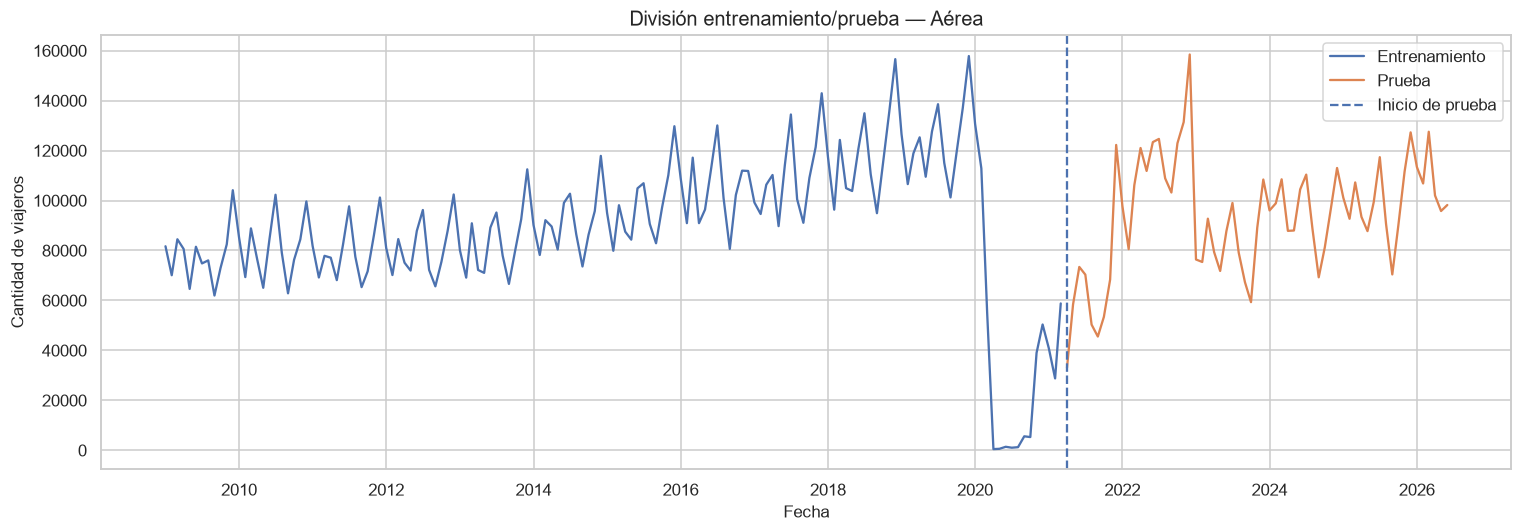

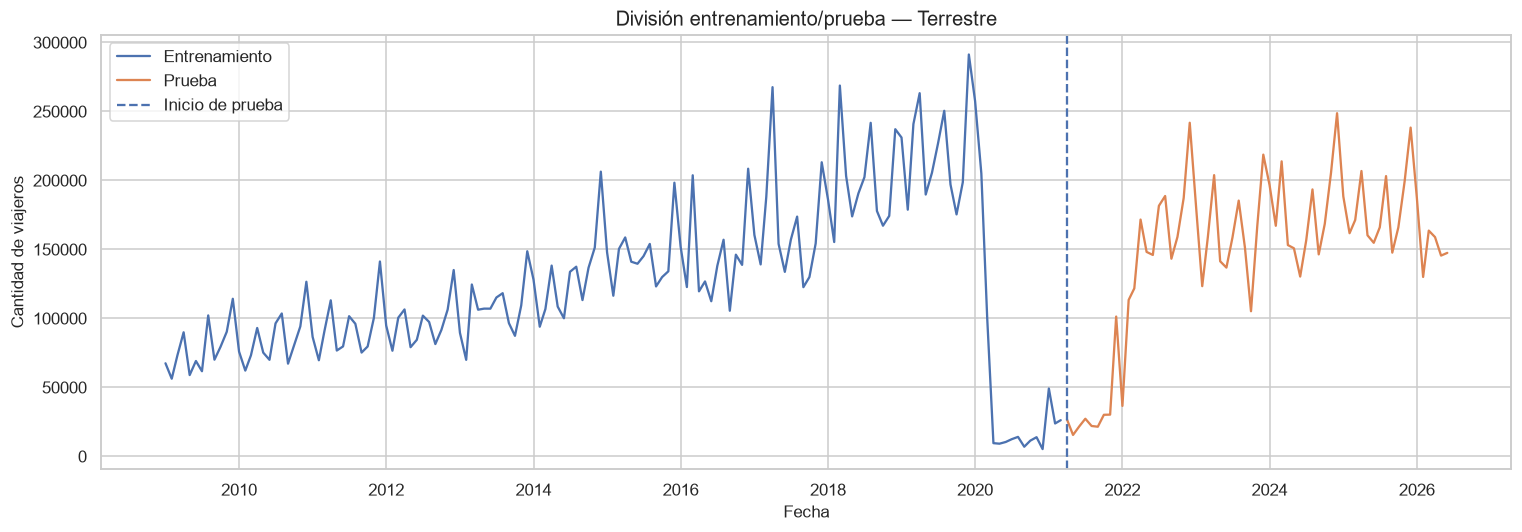

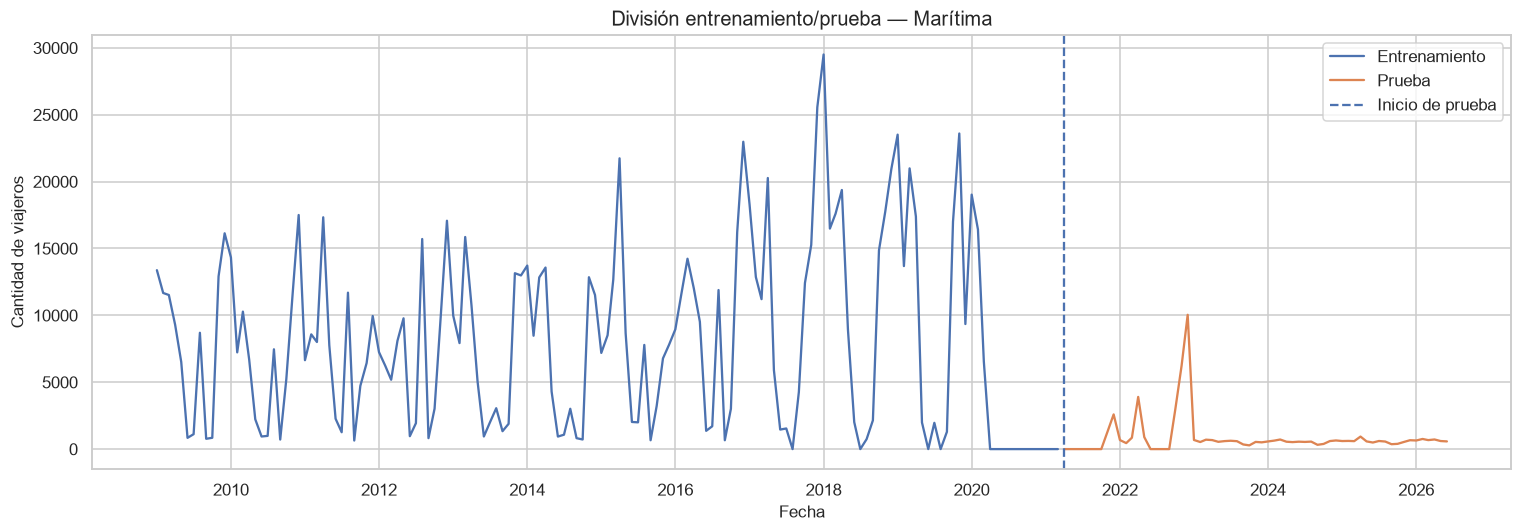

In [25]:
for via in VIAS:
    plt.figure(figsize=(14, 5))

    plt.plot(
        train_vias.index,
        train_vias[via],
        label="Entrenamiento"
    )

    plt.plot(
        test_vias.index,
        test_vias[via],
        label="Prueba"
    )

    plt.axvline(
        test_vias.index.min(),
        linestyle="--",
        label="Inicio de prueba"
    )

    plt.title(
        f"División entrenamiento/prueba — {via}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [26]:
revision_maritima_split = pd.Series({
    "Suma_train": train_vias["Marítima"].sum(),
    "Suma_test": test_vias["Marítima"].sum(),
    "Meses_positivos_train": int(
        (train_vias["Marítima"] > 0).sum()
    ),
    "Meses_positivos_test": int(
        (test_vias["Marítima"] > 0).sum()
    ),
    "Meses_cero_train": int(
        (train_vias["Marítima"] == 0).sum()
    ),
    "Meses_cero_test": int(
        (test_vias["Marítima"] == 0).sum()
    )
})

display(
    revision_maritima_split.to_frame(
        "Marítima"
    )
)

,Marítima
Suma_train,"1,174,705.00"
Suma_test,"54,077.00"
Meses_positivos_train,131.00
Meses_positivos_test,52.00
Meses_cero_train,16.00
Meses_cero_test,11.00


La división 70/30 se realiza en la misma fecha para las tres series y respeta el
orden temporal. El conjunto de prueba marítimo ahora contiene registros
positivos; ya no está compuesto artificialmente por ceros.

---

# Funciones para el análisis de las series

Las funciones siguientes se escriben una sola vez y después se aplican a Aérea,
Terrestre y Marítima. Los resultados, gráficos y conclusiones se muestran por
separado para cumplir con el análisis individual de cada serie.

In [27]:
def prueba_adf(
    serie: pd.Series,
    nombre: str = ""
) -> pd.Series:
    serie_limpia = (
        serie
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    resultado = adfuller(
        serie_limpia,
        autolag="AIC"
    )

    salida = pd.Series({
        "Serie": nombre,
        "Estadístico ADF": resultado[0],
        "p-value": resultado[1],
        "Rezagos utilizados": resultado[2],
        "Observaciones": resultado[3],
        "Valor crítico 1%": resultado[4]["1%"],
        "Valor crítico 5%": resultado[4]["5%"],
        "Valor crítico 10%": resultado[4]["10%"],
        "¿Estacionaria al 5%?": resultado[1] < 0.05
    })

    return salida

In [28]:
def evaluar_varianza(
    serie_train: pd.Series,
    nombre: str,
    ventana: int = 12
) -> dict:
    serie = serie_train.astype(float).copy()

    media_movil_original = (
        serie.rolling(ventana).mean()
    )

    desviacion_movil_original = (
        serie.rolling(ventana).std()
    )

    correlacion_original = (
        media_movil_original
        .corr(desviacion_movil_original)
    )

    serie_log = np.log1p(serie)

    media_movil_log = (
        serie_log.rolling(ventana).mean()
    )

    desviacion_movil_log = (
        serie_log.rolling(ventana).std()
    )

    correlacion_log = (
        media_movil_log
        .corr(desviacion_movil_log)
    )

    figura, ejes = plt.subplots(
        2,
        1,
        figsize=(14, 9),
        sharex=True
    )

    ejes[0].plot(
        serie,
        label="Serie original"
    )

    ejes[0].plot(
        media_movil_original,
        label="Media móvil de 12 meses"
    )

    ejes[0].plot(
        desviacion_movil_original,
        label="Desviación móvil de 12 meses"
    )

    ejes[0].set_title(
        f"Evaluación de varianza original — {nombre}"
    )

    ejes[0].legend()

    ejes[1].plot(
        serie_log,
        label="Serie transformada con log1p"
    )

    ejes[1].plot(
        media_movil_log,
        label="Media móvil"
    )

    ejes[1].plot(
        desviacion_movil_log,
        label="Desviación móvil"
    )

    ejes[1].set_title(
        f"Evaluación de varianza después de log1p — {nombre}"
    )

    ejes[1].legend()

    plt.tight_layout()
    plt.show()

    # Se considera evidencia de varianza no constante cuando
    # media y desviación móvil se mueven claramente juntas.
    usar_log = (
        pd.notna(correlacion_original)
        and pd.notna(correlacion_log)
        and abs(correlacion_original) >= 0.40
        and abs(correlacion_log) < abs(correlacion_original)
    )

    transformacion = (
        "log1p"
        if usar_log
        else "ninguna"
    )

    tabla = pd.DataFrame({
        "Versión": [
            "Original",
            "log1p"
        ],
        "Correlación_media_desviación": [
            correlacion_original,
            correlacion_log
        ]
    })

    display(tabla)

    print(
        f"Transformación seleccionada para {nombre}: "
        f"{transformacion}"
    )

    if transformacion == "log1p":
        print(
            "La transformación log1p reduce la relación entre "
            "el nivel de la serie y su variabilidad."
        )
    else:
        print(
            "No se observa una mejora suficiente con log1p; "
            "se conserva la escala original."
        )

    return {
        "transformacion": transformacion,
        "serie_modelo": (
            serie_log
            if transformacion == "log1p"
            else serie
        ),
        "correlacion_original": correlacion_original,
        "correlacion_log": correlacion_log
    }

In [29]:
def aplicar_transformacion(
    serie: pd.Series,
    transformacion: str
) -> pd.Series:
    if transformacion == "log1p":
        return np.log1p(serie)

    return serie.astype(float).copy()


def invertir_transformacion(
    serie: pd.Series,
    transformacion: str
) -> pd.Series:
    if transformacion == "log1p":
        return np.expm1(serie)

    return serie.astype(float).copy()

In [30]:
def evaluar_diferenciaciones(
    serie: pd.Series,
    periodo_estacional: int = 12,
    max_d: int = 2
) -> pd.DataFrame:
    resultados = []

    for D in [0, 1]:
        serie_base = serie.copy()

        if D == 1:
            serie_base = (
                serie_base
                .diff(periodo_estacional)
            )

        for d in range(max_d + 1):
            serie_evaluada = (
                serie_base.copy()
            )

            for _ in range(d):
                serie_evaluada = (
                    serie_evaluada.diff()
                )

            serie_evaluada = (
                serie_evaluada
                .dropna()
            )

            try:
                resultado = adfuller(
                    serie_evaluada,
                    autolag="AIC"
                )

                resultados.append({
                    "d": d,
                    "D": D,
                    "s": periodo_estacional,
                    "Estadístico_ADF": resultado[0],
                    "p_value": resultado[1],
                    "Estacionaria_5%": resultado[1] < 0.05,
                    "Observaciones": len(serie_evaluada)
                })

            except Exception:
                resultados.append({
                    "d": d,
                    "D": D,
                    "s": periodo_estacional,
                    "Estadístico_ADF": np.nan,
                    "p_value": np.nan,
                    "Estacionaria_5%": False,
                    "Observaciones": len(serie_evaluada)
                })

    return pd.DataFrame(resultados)

In [31]:
def seleccionar_d_D(
    tabla_diferencias: pd.DataFrame
) -> tuple[int, int]:
    candidatos = (
        tabla_diferencias[
            tabla_diferencias[
                "Estacionaria_5%"
            ]
        ]
        .copy()
    )

    if candidatos.empty:
        return 1, 1

    candidatos["Total_diferencias"] = (
        candidatos["d"]
        + candidatos["D"]
    )

    mejor = (
        candidatos
        .sort_values(
            [
                "Total_diferencias",
                "D",
                "d",
                "p_value"
            ]
        )
        .iloc[0]
    )

    return (
        int(mejor["d"]),
        int(mejor["D"])
    )

In [32]:
def diferenciar_serie(
    serie: pd.Series,
    d: int,
    D: int,
    periodo: int = 12
) -> pd.Series:
    resultado = serie.copy()

    if D == 1:
        resultado = (
            resultado.diff(periodo)
        )

    for _ in range(d):
        resultado = resultado.diff()

    return resultado.dropna()

In [33]:
def sugerir_p_q(
    serie_estacionaria: pd.Series,
    max_lag_corto: int = 3
) -> dict:
    from statsmodels.tsa.stattools import acf, pacf

    serie = serie_estacionaria.dropna()

    limite = (
        1.96
        / np.sqrt(len(serie))
    )

    valores_acf = acf(
        serie,
        nlags=max_lag_corto,
        fft=True
    )

    valores_pacf = pacf(
        serie,
        nlags=max_lag_corto,
        method="ywm"
    )

    lags_acf_significativos = [
        lag
        for lag in range(1, len(valores_acf))
        if abs(valores_acf[lag]) > limite
    ]

    lags_pacf_significativos = [
        lag
        for lag in range(1, len(valores_pacf))
        if abs(valores_pacf[lag]) > limite
    ]

    q_sugerido = (
        max(lags_acf_significativos)
        if lags_acf_significativos
        else 0
    )

    p_sugerido = (
        max(lags_pacf_significativos)
        if lags_pacf_significativos
        else 0
    )

    p_sugerido = min(p_sugerido, 3)
    q_sugerido = min(q_sugerido, 3)

    return {
        "p_sugerido": p_sugerido,
        "q_sugerido": q_sugerido,
        "límite_significancia": limite,
        "lags_acf_significativos": lags_acf_significativos,
        "lags_pacf_significativos": lags_pacf_significativos
    }

In [34]:
def diagnosticar_serie(
    nombre: str,
    serie_completa: pd.Series,
    serie_train: pd.Series,
    periodo: int = 12
) -> dict:
    print("=" * 80)
    print(f"ANÁLISIS DE LA SERIE: {nombre}")
    print("=" * 80)

    resumen = pd.Series({
        "Inicio": serie_completa.index.min(),
        "Fin": serie_completa.index.max(),
        "Frecuencia": pd.infer_freq(
            serie_completa.index
        ),
        "Observaciones": len(serie_completa),
        "Media": serie_completa.mean(),
        "Mediana": serie_completa.median(),
        "Desviación estándar": serie_completa.std(),
        "Mínimo": serie_completa.min(),
        "Máximo": serie_completa.max(),
        "Meses con cero": int(
            (serie_completa == 0).sum()
        )
    })

    display(
        resumen.to_frame("Valor")
    )

    # Gráfico original
    plt.figure(figsize=(14, 5))

    plt.plot(
        serie_completa.index,
        serie_completa,
        linewidth=1.4
    )

    plt.title(
        f"Serie mensual original — {nombre}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")

    plt.tight_layout()
    plt.show()

    # Descomposición
    resultado_stl = STL(
        serie_completa,
        period=periodo,
        robust=True
    ).fit()

    figura = resultado_stl.plot()
    figura.set_size_inches(14, 9)
    figura.suptitle(
        f"Descomposición STL — {nombre}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    var_residuo = np.var(
        resultado_stl.resid,
        ddof=1
    )

    var_residuo_estacional = np.var(
        resultado_stl.resid
        + resultado_stl.seasonal,
        ddof=1
    )

    var_residuo_tendencia = np.var(
        resultado_stl.resid
        + resultado_stl.trend,
        ddof=1
    )

    fuerza_estacional = max(
        0,
        1 - (
            var_residuo
            / var_residuo_estacional
        )
    )

    fuerza_tendencia = max(
        0,
        1 - (
            var_residuo
            / var_residuo_tendencia
        )
    )

    print(
        "Fuerza de estacionalidad:",
        round(fuerza_estacional, 4)
    )

    print(
        "Fuerza de tendencia:",
        round(fuerza_tendencia, 4)
    )

    if fuerza_estacional >= 0.60:
        print(
            "La serie presenta una estacionalidad fuerte: "
            "los meses del año influyen de forma importante en el flujo."
        )
    elif fuerza_estacional >= 0.30:
        print(
            "La serie presenta una estacionalidad moderada."
        )
    else:
        print(
            "La estacionalidad observada es débil."
        )

    if fuerza_tendencia >= 0.60:
        print(
            "La tendencia explica una parte importante del movimiento de la serie."
        )
    elif fuerza_tendencia >= 0.30:
        print(
            "La serie presenta una tendencia moderada."
        )
    else:
        print(
            "No se observa una tendencia estable fuerte."
        )

    # Estacionariedad en varianza
    diagnostico_varianza = evaluar_varianza(
        serie_train=serie_train,
        nombre=nombre,
        ventana=periodo
    )

    transformacion = (
        diagnostico_varianza[
            "transformacion"
        ]
    )

    serie_train_modelo = aplicar_transformacion(
        serie_train,
        transformacion
    )

    # Estacionariedad en media
    print("\nPrueba ADF antes de diferenciar:")

    adf_original = prueba_adf(
        serie_train_modelo,
        nombre=nombre
    )

    display(
        adf_original.to_frame("Resultado")
    )

    lags_original = min(
        36,
        len(serie_train_modelo) // 2 - 1
    )

    figura, eje = plt.subplots(
        figsize=(13, 5)
    )

    plot_acf(
        serie_train_modelo.dropna(),
        lags=lags_original,
        ax=eje
    )

    eje.set_title(
        f"ACF antes de diferenciar — {nombre}"
    )

    plt.tight_layout()
    plt.show()

    tabla_diferencias = (
        evaluar_diferenciaciones(
            serie=serie_train_modelo,
            periodo_estacional=periodo,
            max_d=2
        )
    )

    display(tabla_diferencias)

    d, D = seleccionar_d_D(
        tabla_diferencias
    )

    print(
        f"Diferenciación seleccionada: "
        f"d={d}, D={D}, s={periodo}"
    )

    serie_estacionaria = diferenciar_serie(
        serie=serie_train_modelo,
        d=d,
        D=D,
        periodo=periodo
    )

    print("\nADF después de diferenciar:")

    adf_final = prueba_adf(
        serie_estacionaria,
        nombre=nombre
    )

    display(
        adf_final.to_frame("Resultado")
    )

    lags_finales = min(
        36,
        len(serie_estacionaria) // 2 - 1
    )

    figura, ejes = plt.subplots(
        2,
        1,
        figsize=(13, 9)
    )

    plot_acf(
        serie_estacionaria,
        lags=lags_finales,
        ax=ejes[0]
    )

    ejes[0].set_title(
        f"ACF de la serie estacionaria — {nombre}"
    )

    plot_pacf(
        serie_estacionaria,
        lags=lags_finales,
        method="ywm",
        ax=ejes[1]
    )

    ejes[1].set_title(
        f"PACF de la serie estacionaria — {nombre}"
    )

    plt.tight_layout()
    plt.show()

    sugerencias = sugerir_p_q(
        serie_estacionaria
    )

    print(
        "p sugerido por la PACF:",
        sugerencias["p_sugerido"]
    )

    print(
        "q sugerido por la ACF:",
        sugerencias["q_sugerido"]
    )

    print(
        "Rezagos significativos en ACF:",
        sugerencias[
            "lags_acf_significativos"
        ]
    )

    print(
        "Rezagos significativos en PACF:",
        sugerencias[
            "lags_pacf_significativos"
        ]
    )

    return {
        "nombre": nombre,
        "resumen": resumen,
        "stl": resultado_stl,
        "fuerza_estacional": fuerza_estacional,
        "fuerza_tendencia": fuerza_tendencia,
        "transformacion": transformacion,
        "serie_train_modelo": serie_train_modelo,
        "adf_original": adf_original,
        "tabla_diferencias": tabla_diferencias,
        "d": d,
        "D": D,
        "serie_estacionaria": serie_estacionaria,
        "adf_final": adf_final,
        "p_sugerido": sugerencias["p_sugerido"],
        "q_sugerido": sugerencias["q_sugerido"]
    }

# Funciones para generar y evaluar modelos

In [35]:
def crear_candidatos_sarima(
    p_sugerido: int,
    q_sugerido: int,
    d: int,
    D: int,
    periodo: int = 12
) -> list:
    valores_p = sorted(
        set([
            0,
            1,
            min(2, max(0, p_sugerido)),
            min(3, max(0, p_sugerido))
        ])
    )

    valores_q = sorted(
        set([
            0,
            1,
            min(2, max(0, q_sugerido)),
            min(3, max(0, q_sugerido))
        ])
    )

    ordenes = [
        (p, d, q)
        for p in valores_p
        for q in valores_q
        if not (p == 0 and q == 0 and d == 0)
    ]

    ordenes_estacionales = [
        (0, D, 0, periodo),
        (1, D, 0, periodo),
        (0, D, 1, periodo),
        (1, D, 1, periodo)
    ]

    return list(
        itertools.product(
            ordenes,
            ordenes_estacionales
        )
    )

In [36]:
def ajustar_candidatos_sarima(
    serie_train: pd.Series,
    diagnostico: dict,
    periodo: int = 12
) -> tuple[pd.DataFrame, dict]:
    transformacion = (
        diagnostico["transformacion"]
    )

    serie_modelo = aplicar_transformacion(
        serie_train,
        transformacion
    )

    candidatos = crear_candidatos_sarima(
        p_sugerido=diagnostico[
            "p_sugerido"
        ],
        q_sugerido=diagnostico[
            "q_sugerido"
        ],
        d=diagnostico["d"],
        D=diagnostico["D"],
        periodo=periodo
    )

    filas = []
    modelos = {}

    for orden, orden_estacional in candidatos:
        nombre_modelo = (
            f"SARIMA{orden}x{orden_estacional}"
        )

        try:
            modelo = SARIMAX(
                serie_modelo,
                order=orden,
                seasonal_order=orden_estacional,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            ajuste = modelo.fit(
                disp=False,
                maxiter=300
            )

            residuos = (
                ajuste.resid
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .dropna()
            )

            lag_ljung = min(
                12,
                max(
                    1,
                    len(residuos) // 5
                )
            )

            ljung = acorr_ljungbox(
                residuos,
                lags=[lag_ljung],
                return_df=True
            )

            p_ljung = (
                ljung["lb_pvalue"]
                .iloc[-1]
            )

            filas.append({
                "Modelo": nombre_modelo,
                "Orden": orden,
                "Orden_estacional": orden_estacional,
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "Ljung_Box_p_entrenamiento": p_ljung,
                "Residuos_sin_autocorrelación":
                    p_ljung > 0.05
            })

            modelos[nombre_modelo] = (
                ajuste
            )

        except Exception as error:
            filas.append({
                "Modelo": nombre_modelo,
                "Orden": orden,
                "Orden_estacional": orden_estacional,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung_Box_p_entrenamiento": np.nan,
                "Residuos_sin_autocorrelación": False,
                "Error": str(error)
            })

    tabla = (
        pd.DataFrame(filas)
        .dropna(subset=["AIC", "BIC"])
        .sort_values(
            [
                "BIC",
                "AIC"
            ]
        )
        .reset_index(drop=True)
    )

    if tabla.empty:
        raise RuntimeError(
            "No fue posible ajustar ningún candidato SARIMA."
        )

    return tabla, modelos

In [37]:
def seleccionar_mejor_sarima(
    tabla_sarima: pd.DataFrame
) -> pd.Series:
    residuos_aceptables = tabla_sarima[
        tabla_sarima[
            "Residuos_sin_autocorrelación"
        ]
    ]

    if not residuos_aceptables.empty:
        return (
            residuos_aceptables
            .sort_values(["BIC", "AIC"])
            .iloc[0]
        )

    return (
        tabla_sarima
        .sort_values(["BIC", "AIC"])
        .iloc[0]
    )

In [38]:
def predecir_seasonal_naive(
    train: pd.Series,
    test: pd.Series,
    periodo: int = 12
) -> pd.Series:
    ultima_temporada = (
        train.iloc[-periodo:]
        .to_numpy()
    )

    repeticiones = int(
        np.ceil(
            len(test)
            / periodo
        )
    )

    valores = np.tile(
        ultima_temporada,
        repeticiones
    )[:len(test)]

    return pd.Series(
        valores,
        index=test.index,
        name="Seasonal Naive"
    )

In [39]:
def calcular_metricas(
    real: pd.Series,
    prediccion: pd.Series
) -> dict:
    real_alineado, pred_alineada = real.align(
        prediccion,
        join="inner"
    )

    mascara = (
        real_alineado.notna()
        & pred_alineada.notna()
    )

    real_alineado = real_alineado[mascara]
    pred_alineada = pred_alineada[mascara]

    mae = mean_absolute_error(
        real_alineado,
        pred_alineada
    )

    rmse = np.sqrt(
        mean_squared_error(
            real_alineado,
            pred_alineada
        )
    )

    residuos = (
        real_alineado
        - pred_alineada
    )

    sesgo = residuos.mean()

    lag_ljung = min(
        12,
        max(
            1,
            len(residuos) // 5
        )
    )

    try:
        ljung = acorr_ljungbox(
            residuos,
            lags=[lag_ljung],
            return_df=True
        )

        p_ljung = (
            ljung["lb_pvalue"]
            .iloc[-1]
        )

    except Exception:
        p_ljung = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Sesgo_medio": sesgo,
        "Ljung_Box_p_prueba": p_ljung,
        "Residuos_prueba_sin_autocorrelación":
            (
                p_ljung > 0.05
                if pd.notna(p_ljung)
                else False
            )
    }

In [47]:
def modelar_serie(
    nombre: str,
    train: pd.Series,
    test: pd.Series,
    diagnostico: dict,
    periodo: int = 12
) -> dict:
    print("=" * 80)
    print(f"MODELOS PARA LA SERIE: {nombre}")
    print("=" * 80)

    transformacion = (
        diagnostico["transformacion"]
    )

    # ---------------------------------------------------------
    # ARIMA / SARIMA
    # ---------------------------------------------------------
    tabla_sarima, modelos_sarima = (
        ajustar_candidatos_sarima(
            serie_train=train,
            diagnostico=diagnostico,
            periodo=periodo
        )
    )

    print(
        "Candidatos ARIMA/SARIMA ordenados por BIC:"
    )

    display(
        tabla_sarima.head(15)
    )

    mejor_fila_sarima = (
        seleccionar_mejor_sarima(
            tabla_sarima
        )
    )

    mejor_nombre_sarima = (
        mejor_fila_sarima["Modelo"]
    )

    mejor_sarima = (
        modelos_sarima[
            mejor_nombre_sarima
        ]
    )

    print(
        "Modelo SARIMA seleccionado:",
        mejor_nombre_sarima
    )

    print(
        "Se priorizó un BIC bajo y, cuando fue posible, "
        "residuos sin autocorrelación significativa."
    )

    pred_sarima_transformada = (
        mejor_sarima
        .get_forecast(
            steps=len(test)
        )
        .predicted_mean
    )

    pred_sarima_transformada.index = (
        test.index
    )

    pred_sarima = (
        invertir_transformacion(
            pred_sarima_transformada,
            transformacion
        )
        .clip(lower=0)
        .rename("ARIMA/SARIMA")
    )

    # ---------------------------------------------------------
    # Seasonal Naive
    # ---------------------------------------------------------
    pred_naive = predecir_seasonal_naive(
        train=train,
        test=test,
        periodo=periodo
    )

    # ---------------------------------------------------------
    # Suavizamiento exponencial simple
    # ---------------------------------------------------------
    modelo_ses = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        optimized=True
    )

    pred_ses = (
        modelo_ses
        .forecast(len(test))
    )

    pred_ses.index = test.index

    pred_ses = (
        pred_ses
        .clip(lower=0)
        .rename(
            "Suavizamiento exponencial"
        )
    )

    # ---------------------------------------------------------
    # Holt-Winters
    # ---------------------------------------------------------
    modelo_hw = ExponentialSmoothing(
        train,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=periodo,
        initialization_method="estimated"
    ).fit(
        optimized=True
    )

    pred_hw = (
        modelo_hw
        .forecast(len(test))
    )

    pred_hw.index = test.index

    pred_hw = (
        pred_hw
        .clip(lower=0)
        .rename("Holt-Winters")
    )

    # ---------------------------------------------------------
    # Prophet
    # ---------------------------------------------------------
    modelo_prophet = None
    pred_prophet = None

    datos_prophet = pd.DataFrame({
        "ds": train.index,
        "y": train.values
    })

    modelo_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive"
    )

    modelo_prophet.fit(
        datos_prophet
    )

    futuro = pd.DataFrame({
        "ds": test.index
    })

    pronostico_prophet = (
        modelo_prophet
        .predict(futuro)
    )

    pred_prophet = pd.Series(
        pronostico_prophet[
            "yhat"
        ].to_numpy(),
        index=test.index,
        name="Prophet"
    ).clip(lower=0)

    # ---------------------------------------------------------
    # Tabla de predicciones
    # ---------------------------------------------------------
    predicciones = pd.DataFrame({
        "Real": test,
        "ARIMA/SARIMA": pred_sarima,
        "Seasonal Naive": pred_naive,
        "Suavizamiento exponencial": pred_ses,
        "Holt-Winters": pred_hw
    })

    if pred_prophet is not None:
        predicciones["Prophet"] = (
            pred_prophet
        )

    # ---------------------------------------------------------
    # Métricas de prueba
    # ---------------------------------------------------------
    filas_metricas = []

    for nombre_modelo in (
        predicciones.columns.drop("Real")
    ):
        metricas = calcular_metricas(
            predicciones["Real"],
            predicciones[nombre_modelo]
        )

        fila = {
            "Modelo": nombre_modelo,
            **metricas,
            "AIC": np.nan,
            "BIC": np.nan
        }

        if nombre_modelo == "ARIMA/SARIMA":
            fila["AIC"] = (
                mejor_fila_sarima["AIC"]
            )
            fila["BIC"] = (
                mejor_fila_sarima["BIC"]
            )

        elif nombre_modelo == "Suavizamiento exponencial":
            fila["AIC"] = getattr(
                modelo_ses,
                "aic",
                np.nan
            )
            fila["BIC"] = getattr(
                modelo_ses,
                "bic",
                np.nan
            )

        elif nombre_modelo == "Holt-Winters":
            fila["AIC"] = getattr(
                modelo_hw,
                "aic",
                np.nan
            )
            fila["BIC"] = getattr(
                modelo_hw,
                "bic",
                np.nan
            )

        filas_metricas.append(fila)

    tabla_metricas = (
        pd.DataFrame(filas_metricas)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    print(
        "Comparación de modelos en el conjunto de prueba:"
    )

    display(tabla_metricas)

    # ---------------------------------------------------------
    # Gráfico de pronósticos
    # ---------------------------------------------------------
    plt.figure(figsize=(15, 7))

    # Se muestran los últimos 48 meses de entrenamiento
    # para facilitar la lectura del gráfico.
    train_visible = train.iloc[-48:]

    plt.plot(
        train_visible.index,
        train_visible,
        label="Entrenamiento",
        linewidth=1.4
    )

    plt.plot(
        test.index,
        test,
        label="Real de prueba",
        linewidth=2
    )

    for modelo in (
        predicciones.columns.drop("Real")
    ):
        plt.plot(
            predicciones.index,
            predicciones[modelo],
            label=modelo,
            alpha=0.85
        )

    plt.title(
        f"Predicciones en el conjunto de prueba — {nombre}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Residuos del mejor SARIMA
    # ---------------------------------------------------------
    residuos_sarima = (
        mejor_sarima.resid
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
    )

    figura, ejes = plt.subplots(
        2,
        1,
        figsize=(14, 8)
    )

    ejes[0].plot(
        residuos_sarima
    )

    ejes[0].axhline(
        0,
        linestyle="--"
    )

    ejes[0].set_title(
        f"Residuos del mejor SARIMA — {nombre}"
    )

    lags_residuos = min(
        36,
        len(residuos_sarima) // 2 - 1
    )

    plot_acf(
        residuos_sarima,
        lags=lags_residuos,
        ax=ejes[1]
    )

    ejes[1].set_title(
        f"ACF de los residuos SARIMA — {nombre}"
    )

    plt.tight_layout()
    plt.show()

    mejor_modelo = (
        tabla_metricas.iloc[0]
    )

    print(
        f"Mejor modelo para {nombre} según RMSE: "
        f"{mejor_modelo['Modelo']}"
    )

    print(
        f"MAE: {mejor_modelo['MAE']:,.2f}"
    )

    print(
        f"RMSE: {mejor_modelo['RMSE']:,.2f}"
    )

    print(
        "El modelo se considera más útil cuando combina un error bajo, "
        "poco sesgo y residuos sin patrones temporales importantes."
    )

    return {
        "tabla_sarima": tabla_sarima,
        "modelos_sarima": modelos_sarima,
        "mejor_fila_sarima": mejor_fila_sarima,
        "mejor_sarima": mejor_sarima,
        "modelo_ses": modelo_ses,
        "modelo_hw": modelo_hw,
        "modelo_prophet": modelo_prophet,
        "predicciones": predicciones,
        "metricas": tabla_metricas,
        "mejor_modelo": mejor_modelo["Modelo"],
        "mejor_rmse": mejor_modelo["RMSE"]
    }

---

# Análisis de la Serie Aérea

## Información general de la serie

In [41]:
serie_aerea = series_vias["Aérea"]
train_aerea = train_vias["Aérea"]
test_aerea = test_vias["Aérea"]

display(
    resumen_series[
        resumen_series["Serie"].eq("Aérea")
    ]
)

,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses_con_cero,Total_acumulado,Media_mensual,Mediana,Desviación_estándar,Mínimo,Máximo
0,Aérea,2009-01-01,2026-06-01,MS,210,0,"19,019,418.55","90,568.66","90,941.00","27,855.30",489.00,"158,463.00"


## Gráfico y Componentes

La descomposición separa la serie observada en tendencia, estacionalidad y
residuos. La fuerza estacional indica qué tan importante es el patrón anual,
mientras que la fuerza de tendencia mide cuánto explica el movimiento de largo
plazo.

ANÁLISIS DE LA SERIE: Aérea


,Valor
Inicio,2009-01-01 00:00:00
Fin,2026-06-01 00:00:00
Frecuencia,MS
Observaciones,210
Media,"90,568.66"
Mediana,"90,941.00"
Desviación estándar,"27,855.30"
Mínimo,489.00
Máximo,"158,463.00"
Meses con cero,0


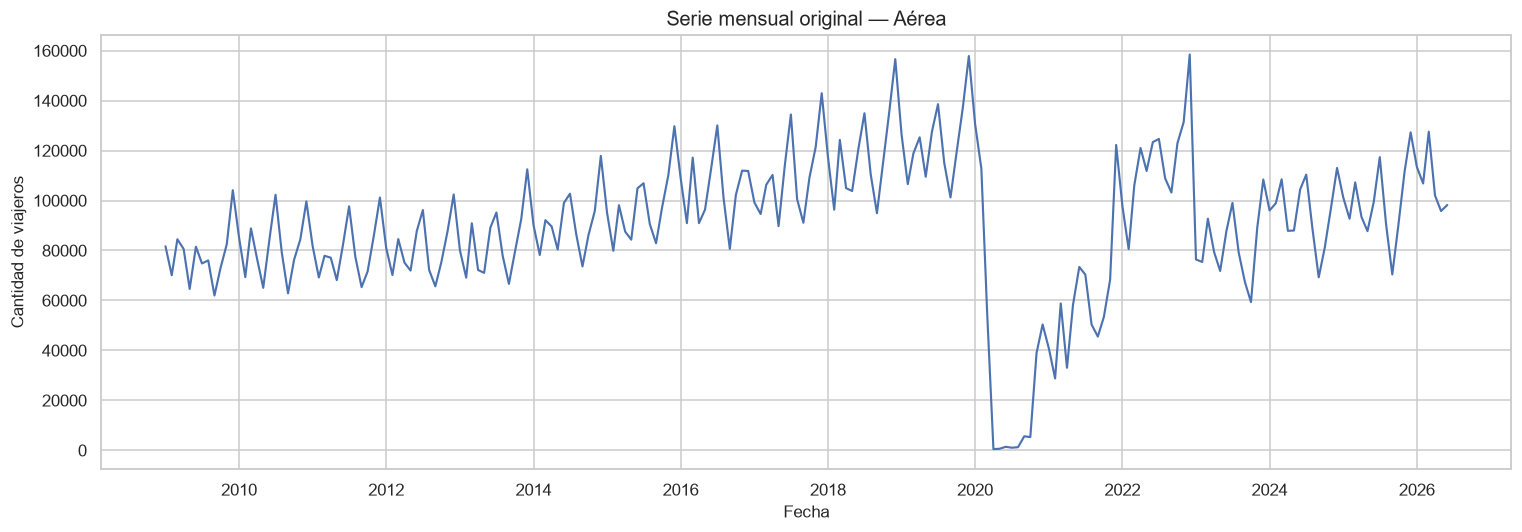

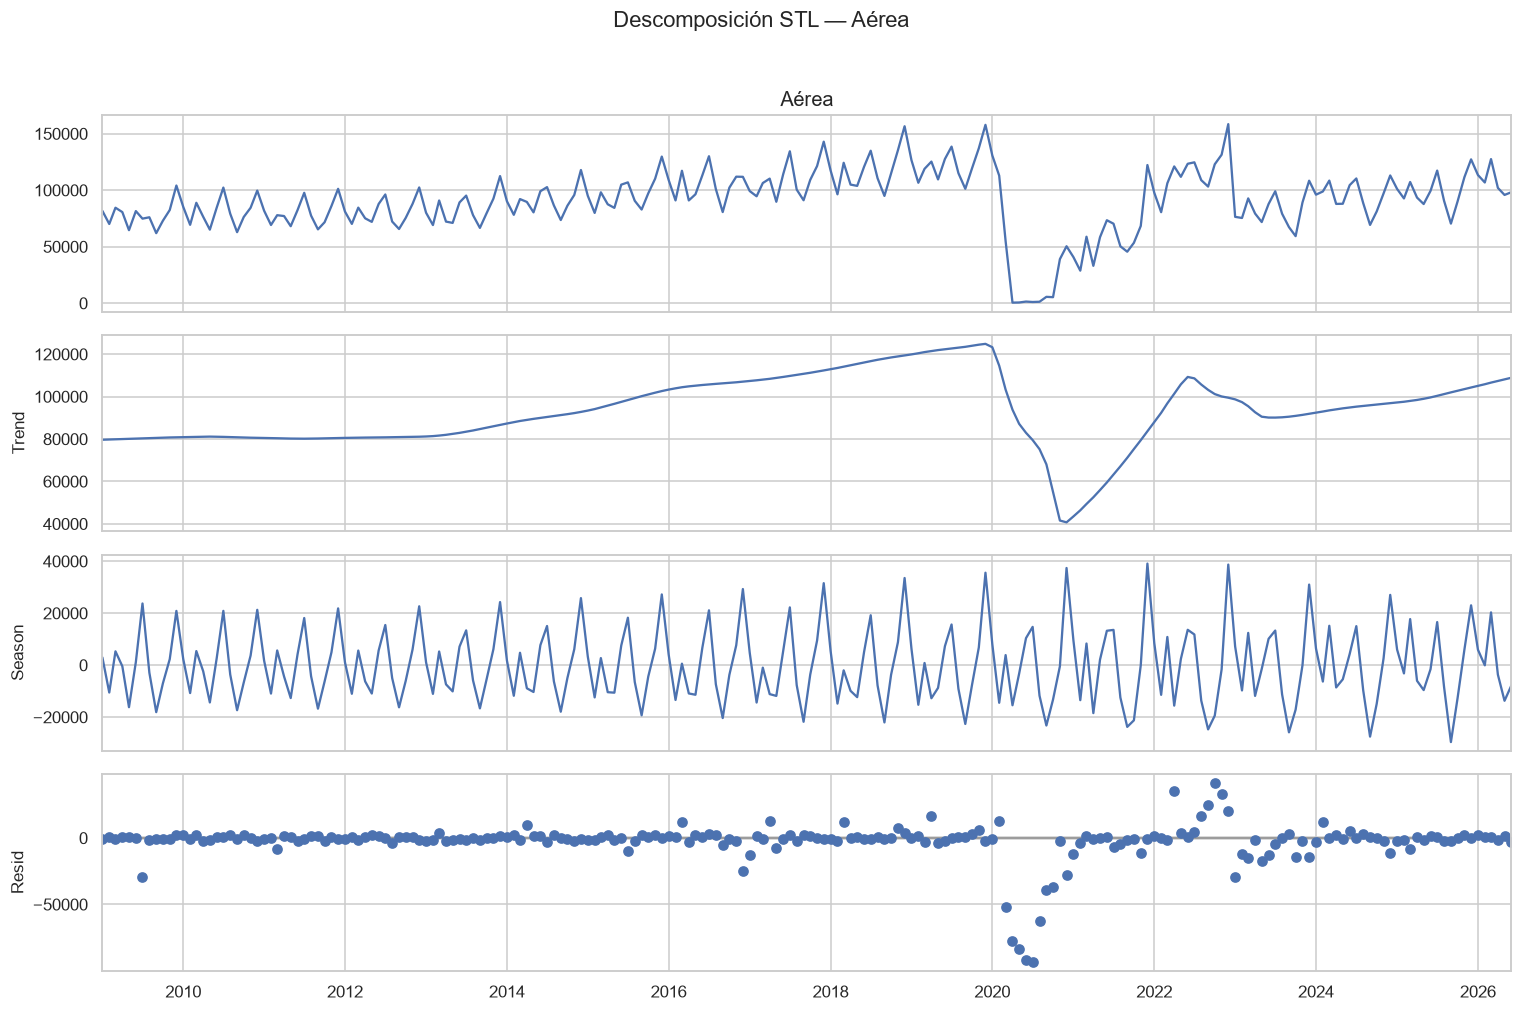

Fuerza de estacionalidad: 0.3843
Fuerza de tendencia: 0.6132
La serie presenta una estacionalidad moderada.
La tendencia explica una parte importante del movimiento de la serie.


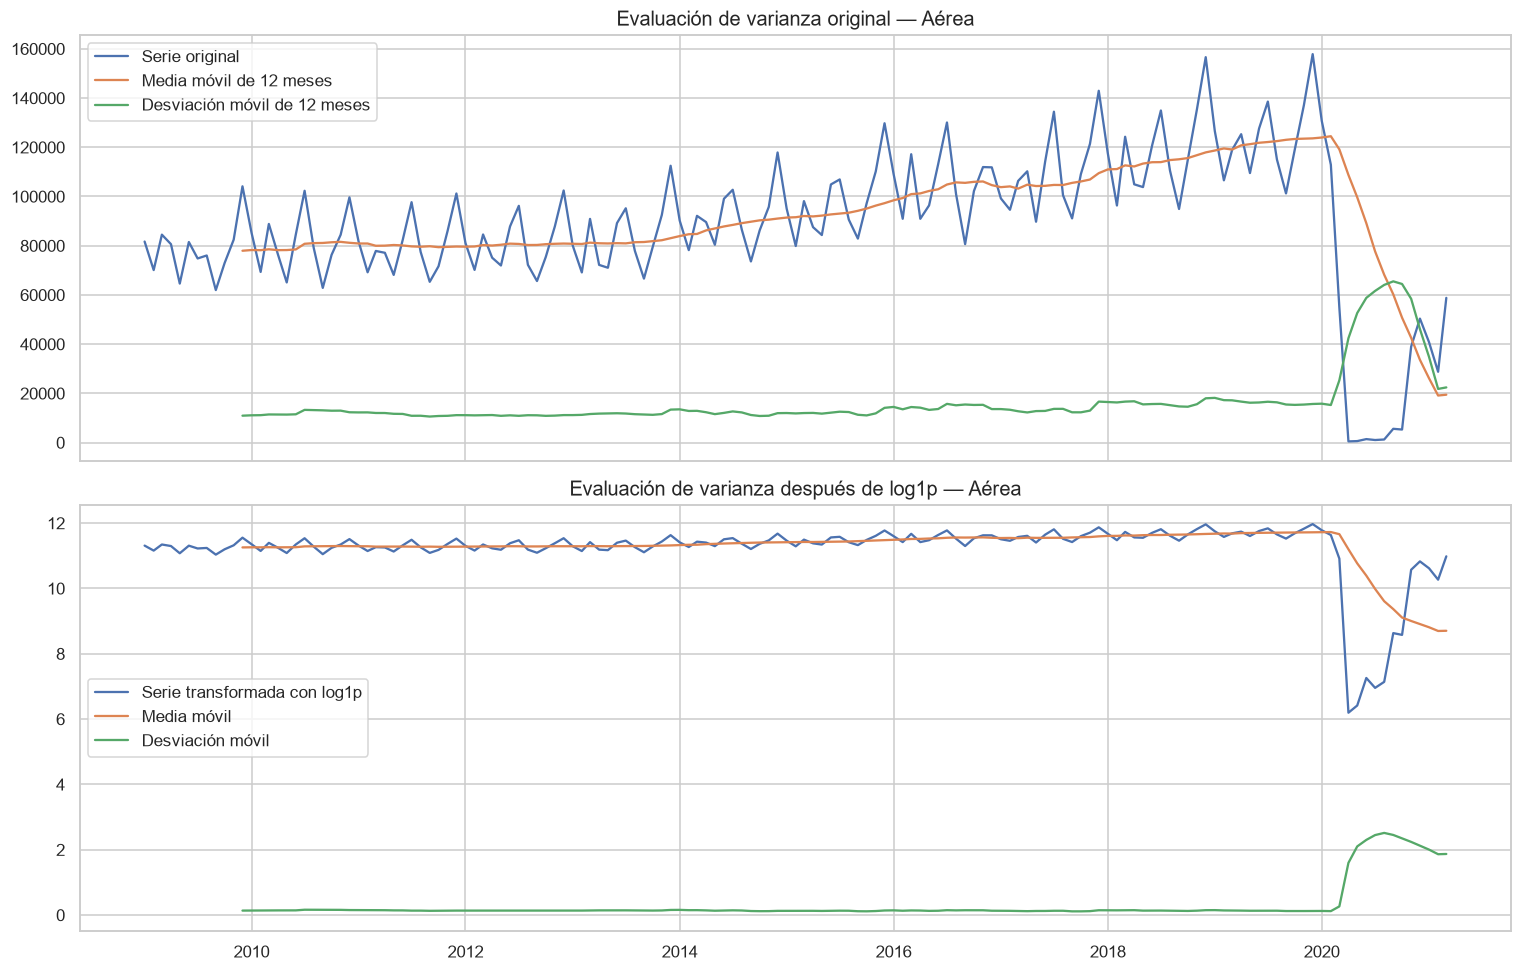

,Versión,Correlación_media_desviación
0,Original,-0.27
1,log1p,-0.88


Transformación seleccionada para Aérea: ninguna
No se observa una mejora suficiente con log1p; se conserva la escala original.

Prueba ADF antes de diferenciar:


,Resultado
Serie,Aérea
Estadístico ADF,-2.37
p-value,0.15
Rezagos utilizados,14
Observaciones,132
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,False


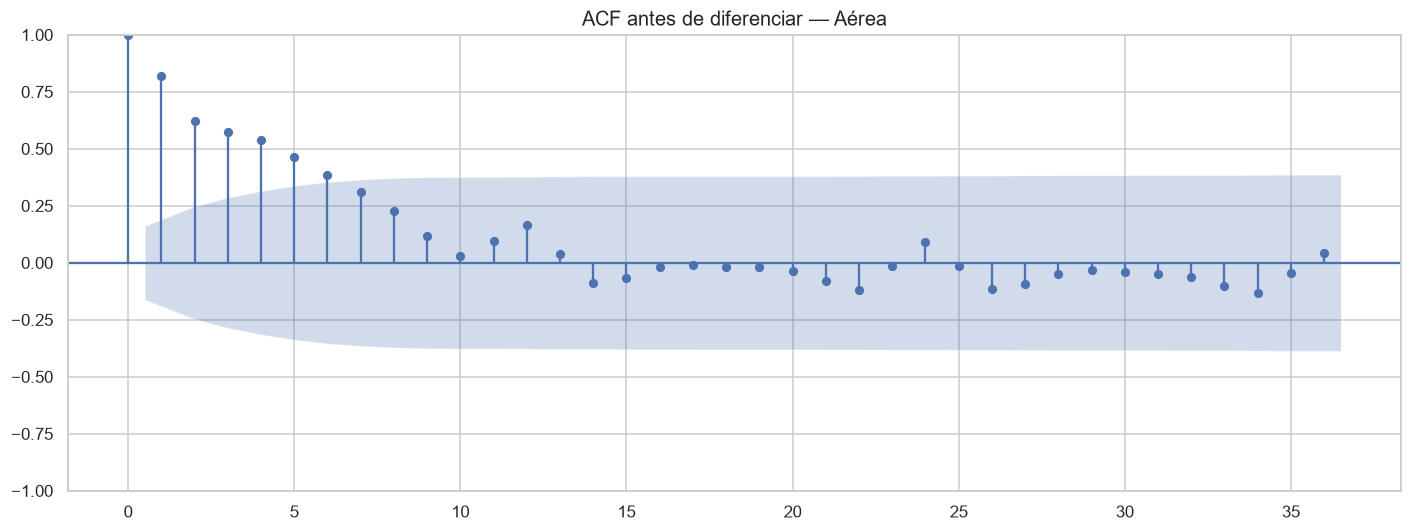

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,-2.37,0.15,False,147
1,1,0,12,-4.07,0.00,True,146
2,2,0,12,-7.34,0.00,True,145
3,0,1,12,-1.19,0.68,False,135
4,1,1,12,-6.36,0.00,True,134
5,2,1,12,-4.15,0.00,True,133


Diferenciación seleccionada: d=1, D=0, s=12

ADF después de diferenciar:


,Resultado
Serie,Aérea
Estadístico ADF,-4.07
p-value,0.00
Rezagos utilizados,14
Observaciones,131
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,True


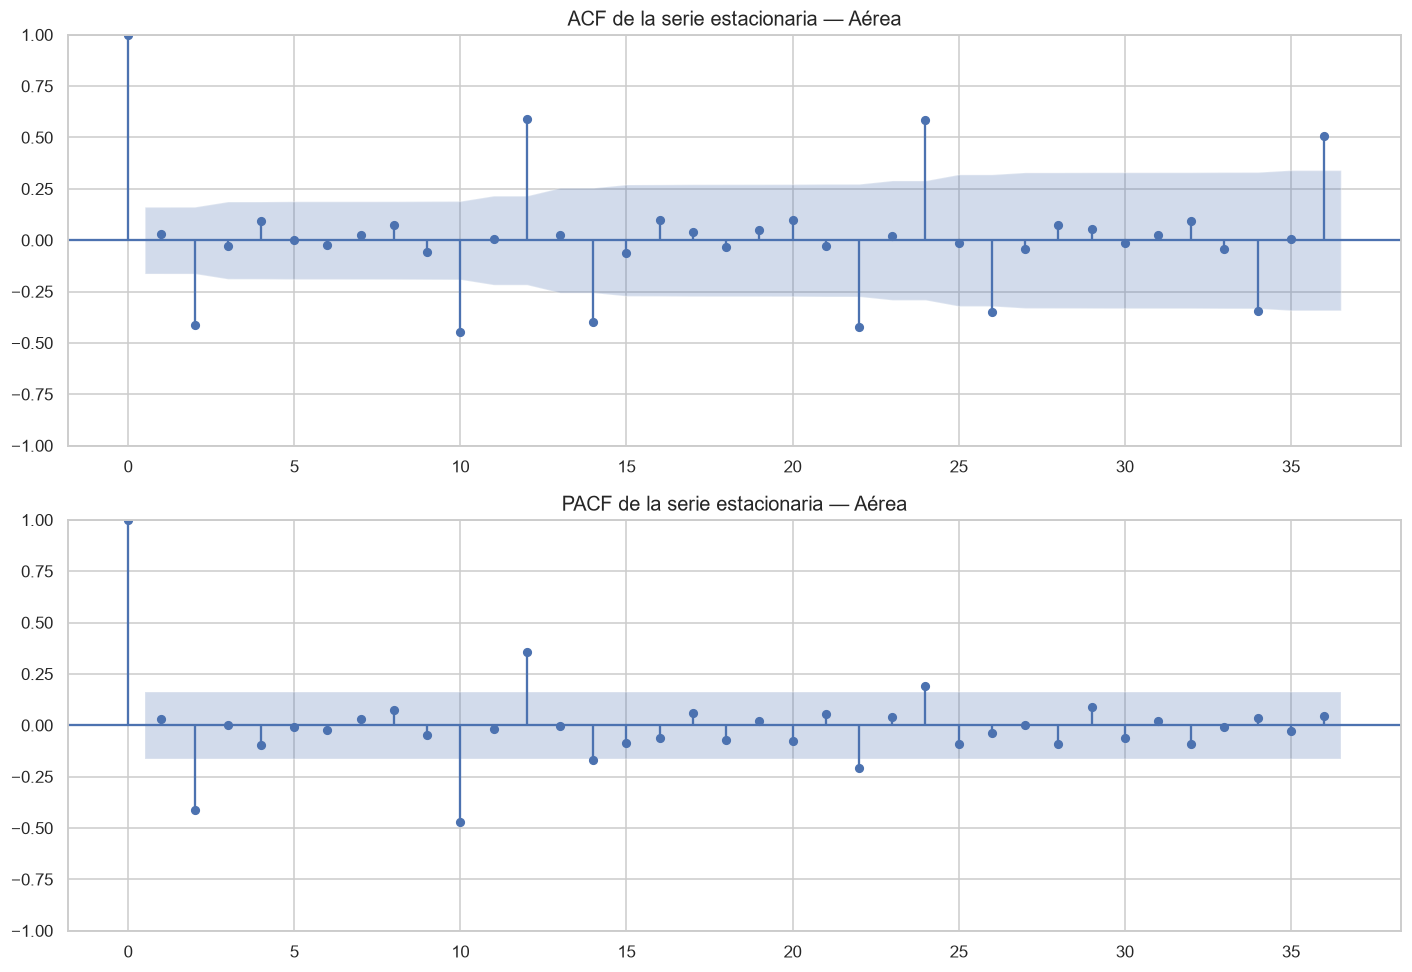

p sugerido por la PACF: 2
q sugerido por la ACF: 2
Rezagos significativos en ACF: [2]
Rezagos significativos en PACF: [2]


In [42]:
diagnostico_aerea = diagnosticar_serie(
    nombre="Aérea",
    serie_completa=serie_aerea,
    serie_train=train_aerea
)

## Estacionariedad en varianza

La función anterior compara la serie original con `log1p`. La transformación se
utiliza únicamente cuando reduce claramente la relación entre la media móvil y
la desviación móvil.

In [43]:
print(
    "Transformación elegida:",
    diagnostico_aerea["transformacion"]
)

display(
    pd.DataFrame({
        "Fuerza_estacional": [
            diagnostico_aerea[
                "fuerza_estacional"
            ]
        ],
        "Fuerza_tendencia": [
            diagnostico_aerea[
                "fuerza_tendencia"
            ]
        ]
    })
)

Transformación elegida: ninguna


,Fuerza_estacional,Fuerza_tendencia
0,0.38,0.61


## Estacionariedad en media

In [44]:
display(
    diagnostico_aerea[
        "tabla_diferencias"
    ]
)

print(
    "d seleccionado:",
    diagnostico_aerea["d"]
)

print(
    "D seleccionado:",
    diagnostico_aerea["D"]
)

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,-2.37,0.15,False,147
1,1,0,12,-4.07,0.00,True,146
2,2,0,12,-7.34,0.00,True,145
3,0,1,12,-1.19,0.68,False,135
4,1,1,12,-6.36,0.00,True,134
5,2,1,12,-4.15,0.00,True,133


d seleccionado: 1
D seleccionado: 0


## Selección de p, d y q

In [45]:
parametros_aerea = pd.Series({
    "p sugerido": diagnostico_aerea[
        "p_sugerido"
    ],
    "d": diagnostico_aerea["d"],
    "q sugerido": diagnostico_aerea[
        "q_sugerido"
    ],
    "D estacional": diagnostico_aerea["D"],
    "Periodo estacional": 12
})

display(
    parametros_aerea.to_frame("Valor")
)

,Valor
p sugerido,2
d,1
q sugerido,2
D estacional,0
Periodo estacional,12


`d` corresponde al número de diferencias regulares necesarias para alcanzar
estacionariedad en media. `D` indica si fue necesaria una diferencia estacional
de 12 meses. `p` se propone con apoyo de la PACF y `q` con apoyo de la ACF. Los
valores cercanos se comparan posteriormente mediante AIC, BIC y residuos.

## Modelos ARIMA

## Modelos alternativos

## Predicción y evaluación de los modelos

MODELOS PARA LA SERIE: Aérea
Candidatos ARIMA/SARIMA ordenados por BIC:


,Modelo,Orden,Orden_estacional,AIC,BIC,Ljung_Box_p_entrenamiento,Residuos_sin_autocorrelación
0,"SARIMA(0, 1, 2)x(1, 0, 1, 12)","(0, 1, 2)","(1, 0, 1, 12)","2,869.86","2,884.24",0.65,True
1,"SARIMA(1, 1, 2)x(1, 0, 1, 12)","(1, 1, 2)","(1, 0, 1, 12)","2,871.72","2,888.97",0.71,True
2,"SARIMA(2, 1, 2)x(1, 0, 1, 12)","(2, 1, 2)","(1, 0, 1, 12)","2,871.85","2,891.98",0.76,True
3,"SARIMA(2, 1, 0)x(1, 0, 1, 12)","(2, 1, 0)","(1, 0, 1, 12)","2,890.76","2,905.17",0.67,True
4,"SARIMA(0, 1, 0)x(1, 0, 1, 12)","(0, 1, 0)","(1, 0, 1, 12)","2,897.17","2,905.84",0.68,True
5,"SARIMA(2, 1, 1)x(1, 0, 1, 12)","(2, 1, 1)","(1, 0, 1, 12)","2,892.82","2,910.12",0.77,True
6,"SARIMA(0, 1, 2)x(0, 0, 1, 12)","(0, 1, 2)","(0, 0, 1, 12)","2,899.01","2,910.51",0.49,True
7,"SARIMA(0, 1, 1)x(1, 0, 1, 12)","(0, 1, 1)","(1, 0, 1, 12)","2,900.21","2,911.74",0.69,True
8,"SARIMA(2, 1, 0)x(1, 0, 0, 12)","(2, 1, 0)","(1, 0, 0, 12)","2,902.00","2,913.53",0.42,True
9,"SARIMA(1, 1, 2)x(0, 0, 1, 12)","(1, 1, 2)","(0, 0, 1, 12)","2,900.98","2,915.36",0.48,True


Modelo SARIMA seleccionado: SARIMA(0, 1, 2)x(1, 0, 1, 12)
Se priorizó un BIC bajo y, cuando fue posible, residuos sin autocorrelación significativa.


22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:08 - cmdstanpy - INFO - Chain [1] done processing


Comparación de modelos en el conjunto de prueba:


,Modelo,MAE,RMSE,Sesgo_medio,Ljung_Box_p_prueba,Residuos_prueba_sin_autocorrelación,AIC,BIC
0,Suavizamiento exponencial,"36,970.60","42,141.22","35,277.85",0.00,False,"2,875.29","2,881.27"
1,Prophet,"41,271.36","45,655.27","37,939.58",0.00,False,NaN,NaN
2,Holt-Winters,"43,072.93","47,051.02","42,577.28",0.00,False,"2,740.96","2,791.79"
3,Seasonal Naive,"75,512.73","79,339.80","75,512.73",0.00,False,NaN,NaN
4,ARIMA/SARIMA,"74,524.43","79,593.05","74,468.57",0.00,False,"2,869.86","2,884.24"


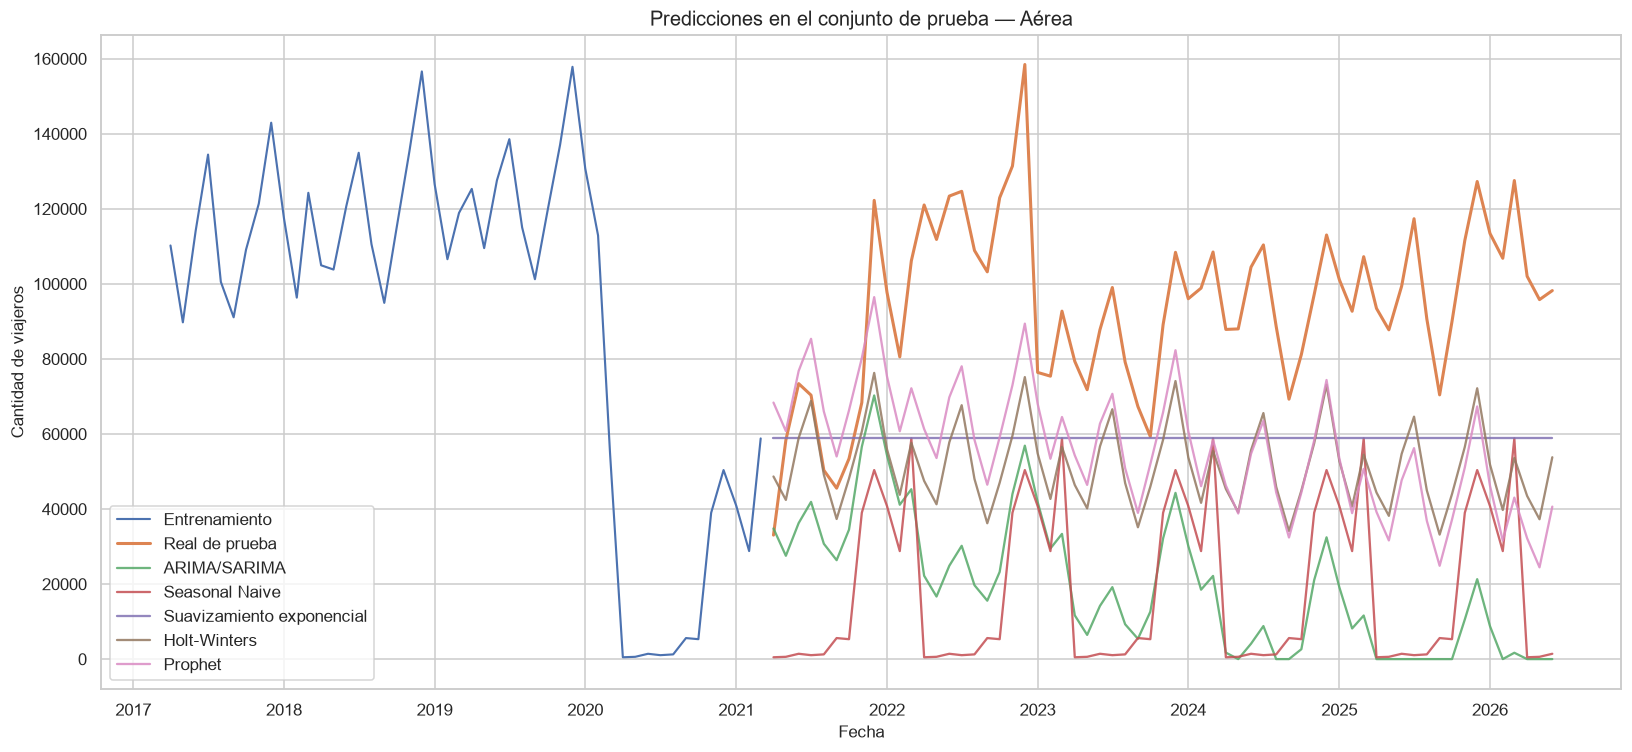

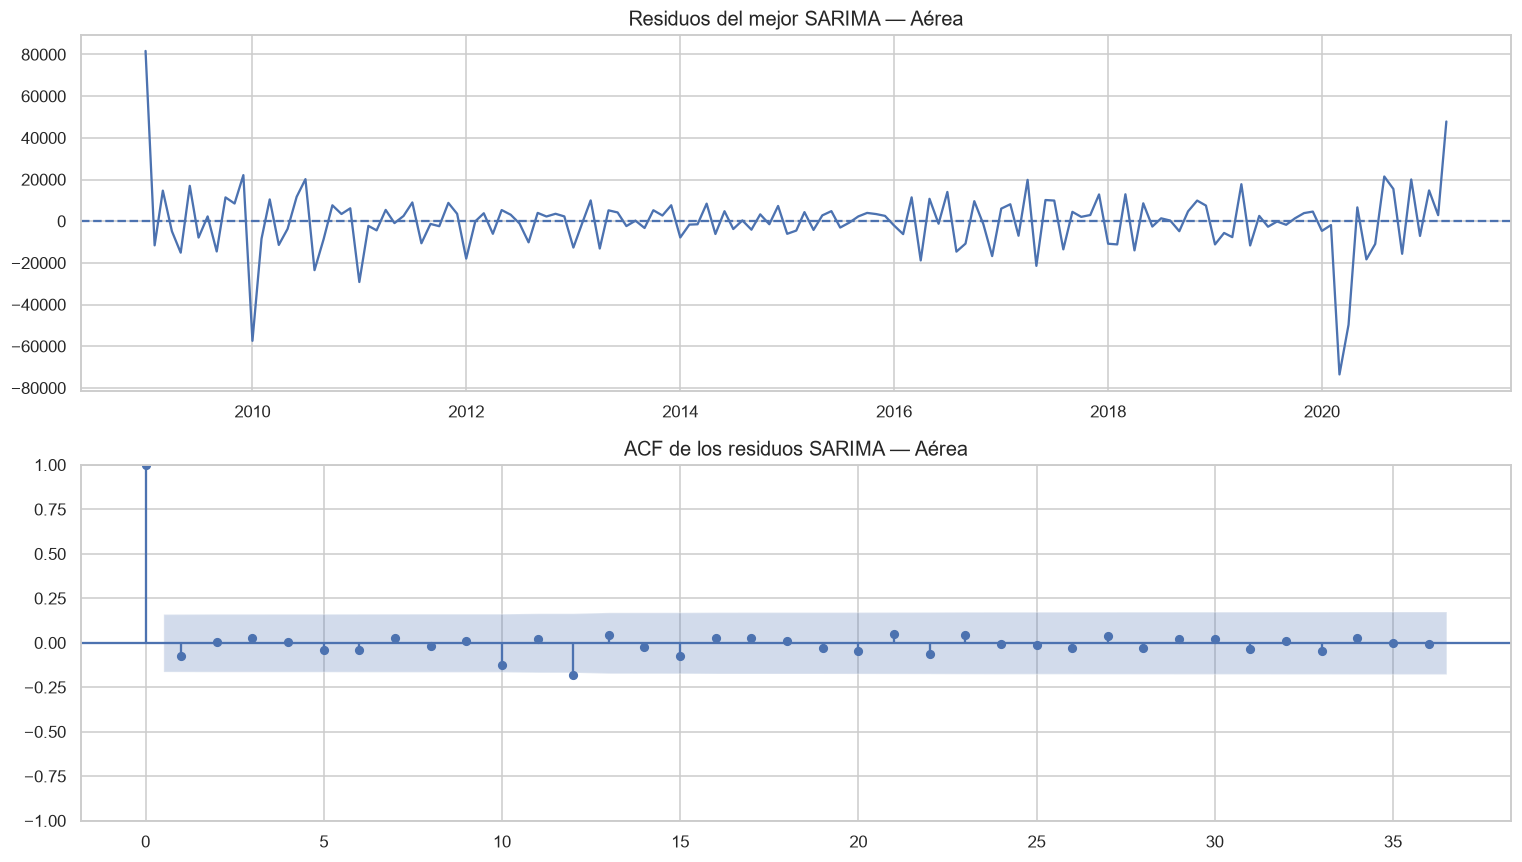

Mejor modelo para Aérea según RMSE: Suavizamiento exponencial
MAE: 36,970.60
RMSE: 42,141.22
El modelo se considera más útil cuando combina un error bajo, poco sesgo y residuos sin patrones temporales importantes.


In [48]:
modelos_aerea = modelar_serie(
    nombre="Aérea",
    train=train_aerea,
    test=test_aerea,
    diagnostico=diagnostico_aerea
)

## Conclusiones

In [49]:
mejor_aerea = (
    modelos_aerea["metricas"]
    .iloc[0]
)

print(
    "CONCLUSIÓN — AÉREA"
)

print(
    f"Fuerza estacional: "
    f"{diagnostico_aerea['fuerza_estacional']:.3f}"
)

print(
    f"Fuerza de tendencia: "
    f"{diagnostico_aerea['fuerza_tendencia']:.3f}"
)

print(
    f"Transformación aplicada: "
    f"{diagnostico_aerea['transformacion']}"
)

print(
    f"Diferenciaciones: "
    f"d={diagnostico_aerea['d']}, "
    f"D={diagnostico_aerea['D']}"
)

print(
    f"Mejor modelo: "
    f"{mejor_aerea['Modelo']}"
)

print(
    f"MAE: {mejor_aerea['MAE']:,.2f}"
)

print(
    f"RMSE: {mejor_aerea['RMSE']:,.2f}"
)

CONCLUSIÓN — AÉREA
Fuerza estacional: 0.384
Fuerza de tendencia: 0.613
Transformación aplicada: ninguna
Diferenciaciones: d=1, D=0
Mejor modelo: Suavizamiento exponencial
MAE: 36,970.60
RMSE: 42,141.22


---

# Análisis de la Serie Terrestre

## Información general de la serie

In [50]:
serie_terrestre = series_vias["Terrestre"]
train_terrestre = train_vias["Terrestre"]
test_terrestre = test_vias["Terrestre"]

display(
    resumen_series[
        resumen_series["Serie"].eq("Terrestre")
    ]
)

,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses_con_cero,Total_acumulado,Media_mensual,Mediana,Desviación_estándar,Mínimo,Máximo
1,Terrestre,2009-01-01,2026-06-01,MS,210,0,"27,592,253.33","131,391.68","134,582.88","60,815.99","5,240.00","291,272.07"


## Gráfico y Componentes

ANÁLISIS DE LA SERIE: Terrestre


,Valor
Inicio,2009-01-01 00:00:00
Fin,2026-06-01 00:00:00
Frecuencia,MS
Observaciones,210
Media,"131,391.68"
Mediana,"134,582.88"
Desviación estándar,"60,815.99"
Mínimo,"5,240.00"
Máximo,"291,272.07"
Meses con cero,0


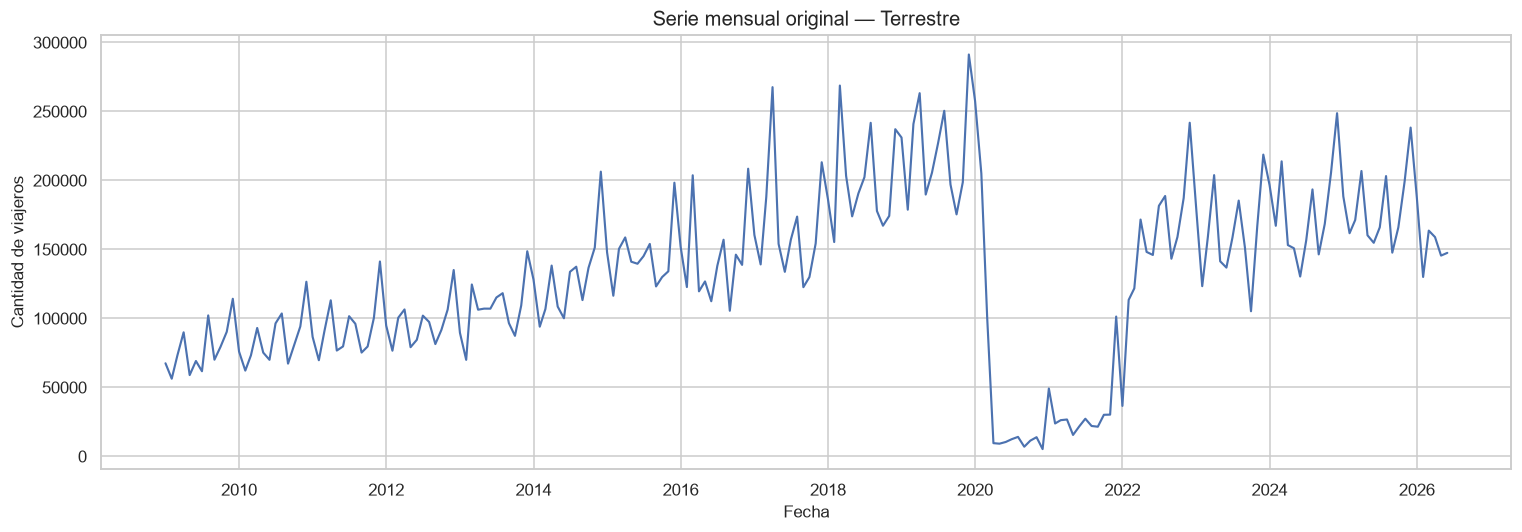

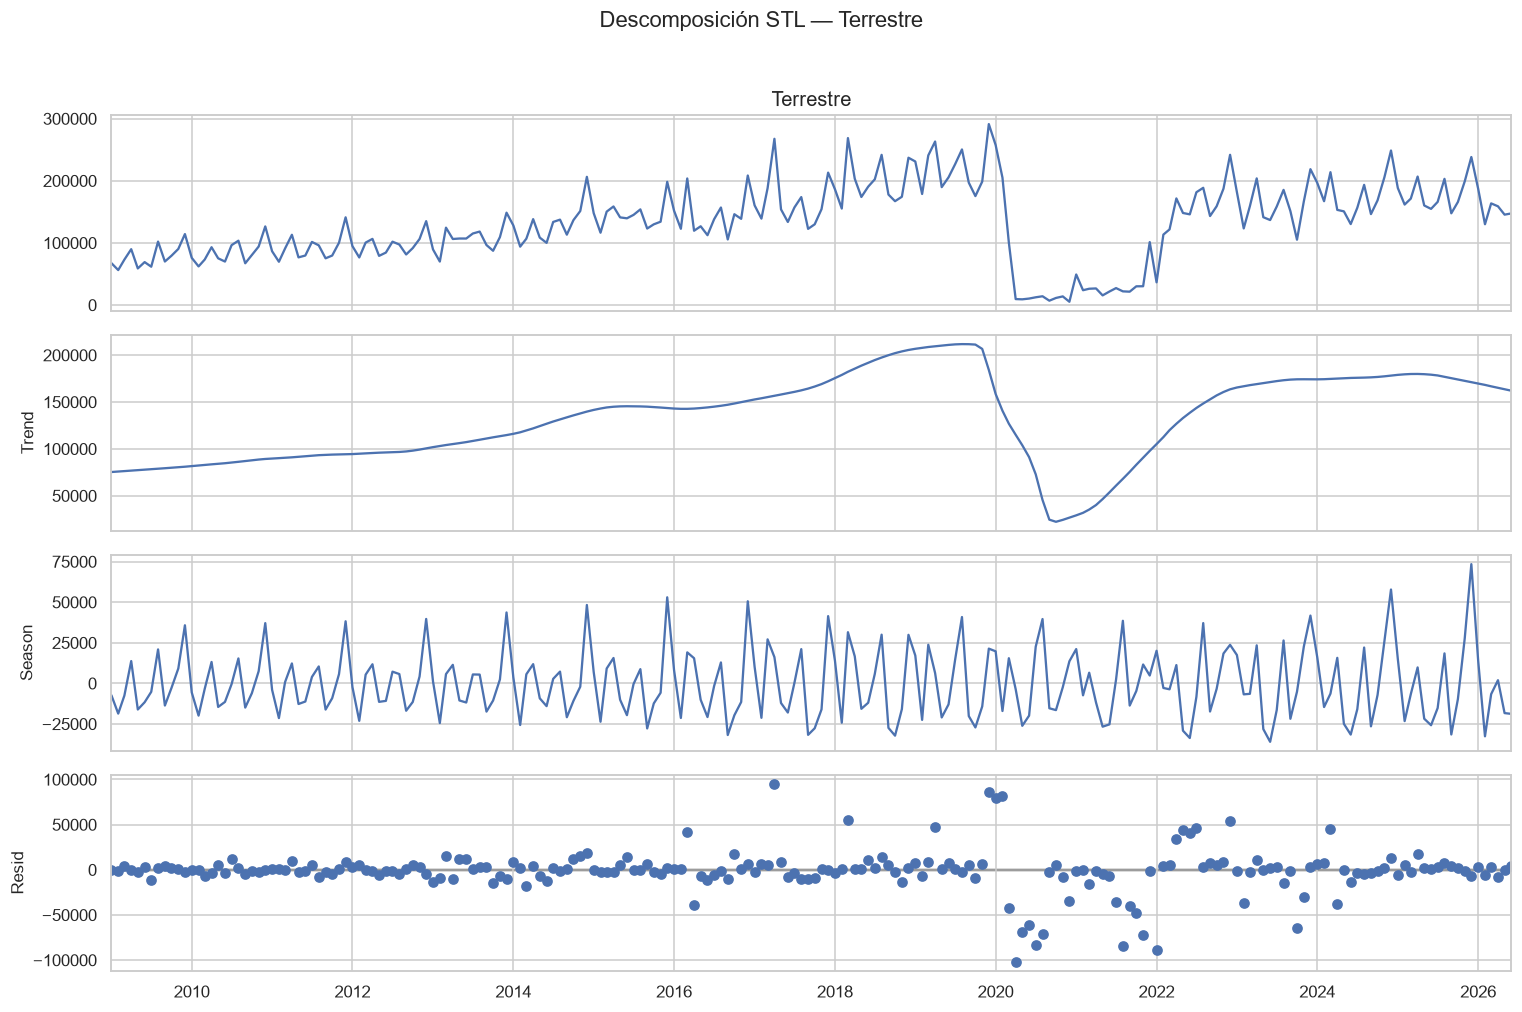

Fuerza de estacionalidad: 0.4094
Fuerza de tendencia: 0.8183
La serie presenta una estacionalidad moderada.
La tendencia explica una parte importante del movimiento de la serie.


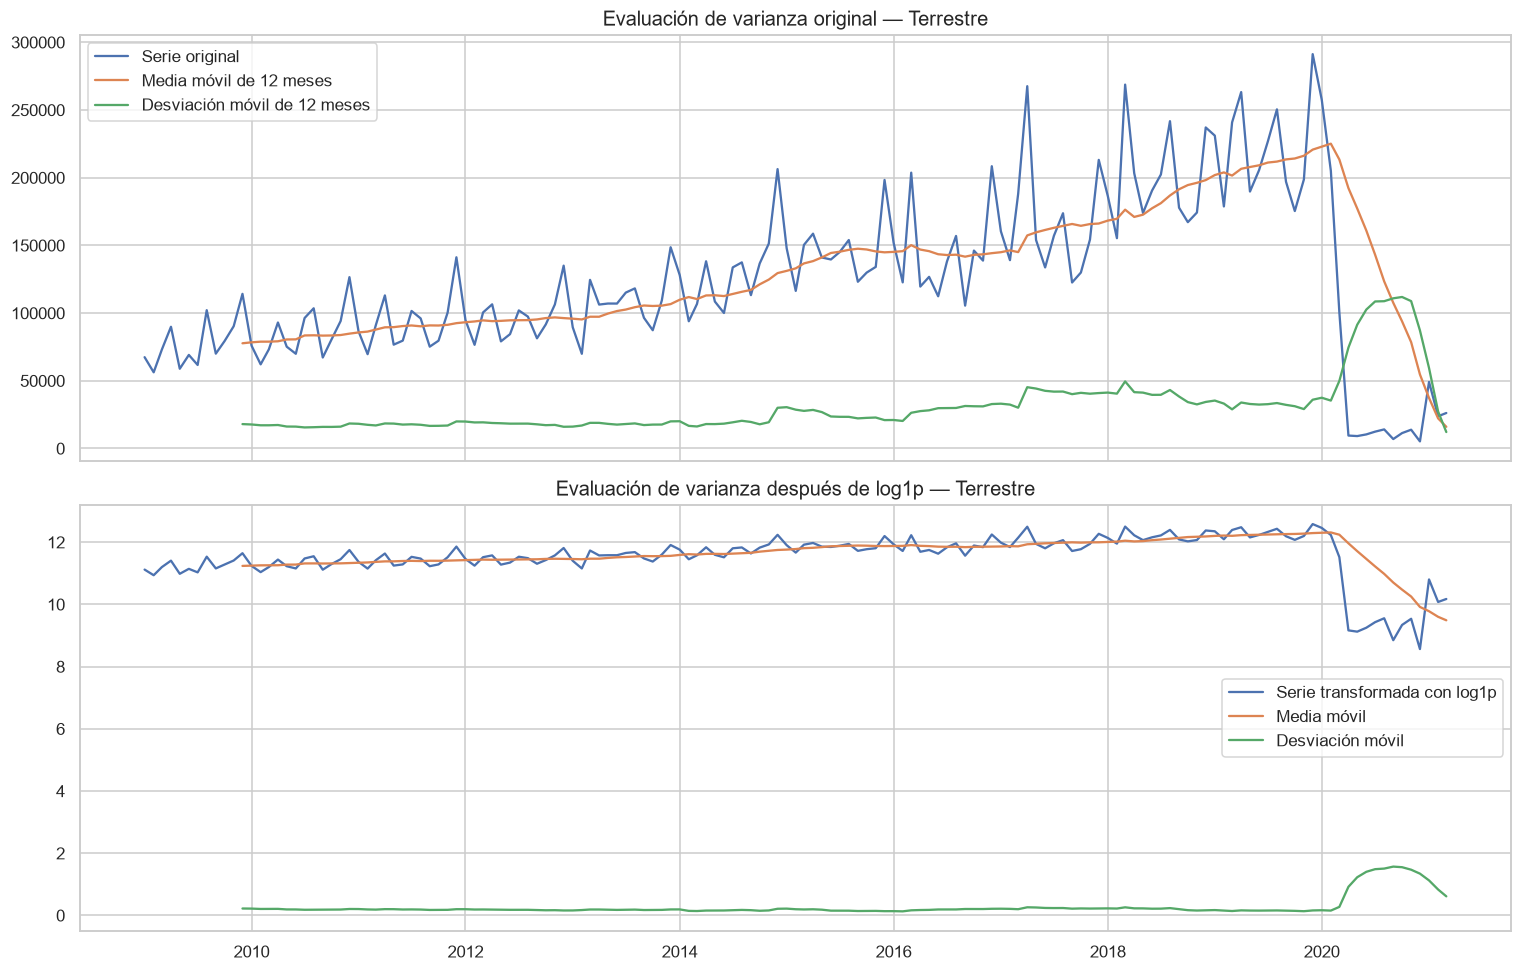

,Versión,Correlación_media_desviación
0,Original,0.26
1,log1p,-0.56


Transformación seleccionada para Terrestre: ninguna
No se observa una mejora suficiente con log1p; se conserva la escala original.

Prueba ADF antes de diferenciar:


,Resultado
Serie,Terrestre
Estadístico ADF,-2.12
p-value,0.24
Rezagos utilizados,13
Observaciones,133
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,False


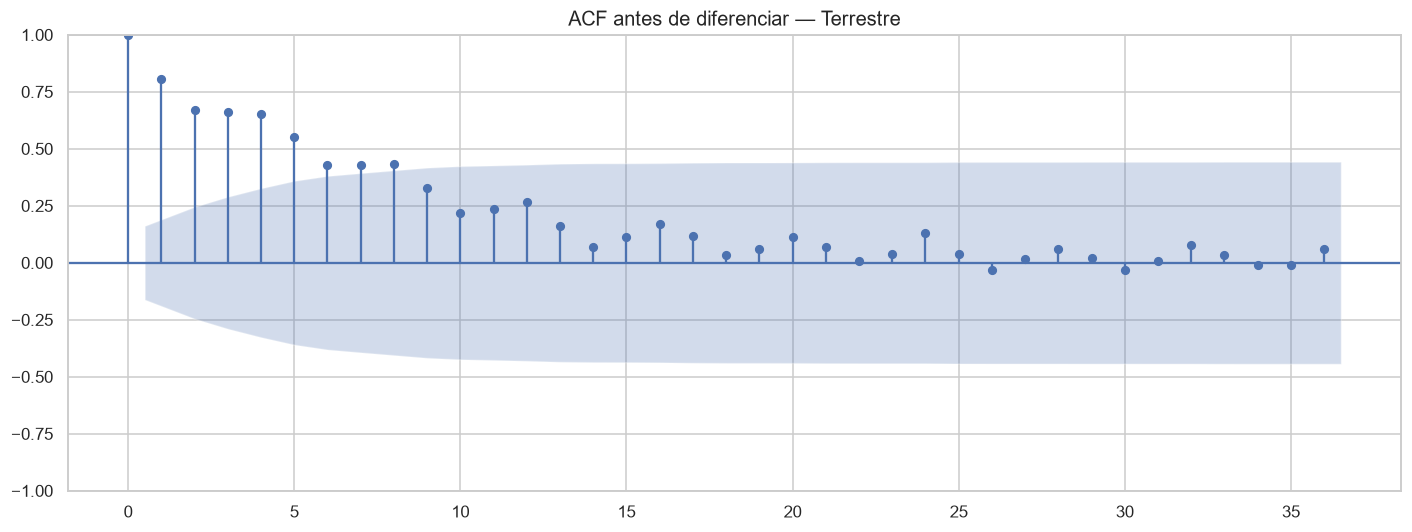

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,-2.12,0.24,False,147
1,1,0,12,-3.33,0.01,True,146
2,2,0,12,-7.22,0.00,True,145
3,0,1,12,-0.62,0.87,False,135
4,1,1,12,-5.05,0.00,True,134
5,2,1,12,-4.31,0.00,True,133


Diferenciación seleccionada: d=1, D=0, s=12

ADF después de diferenciar:


,Resultado
Serie,Terrestre
Estadístico ADF,-3.33
p-value,0.01
Rezagos utilizados,11
Observaciones,134
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,True


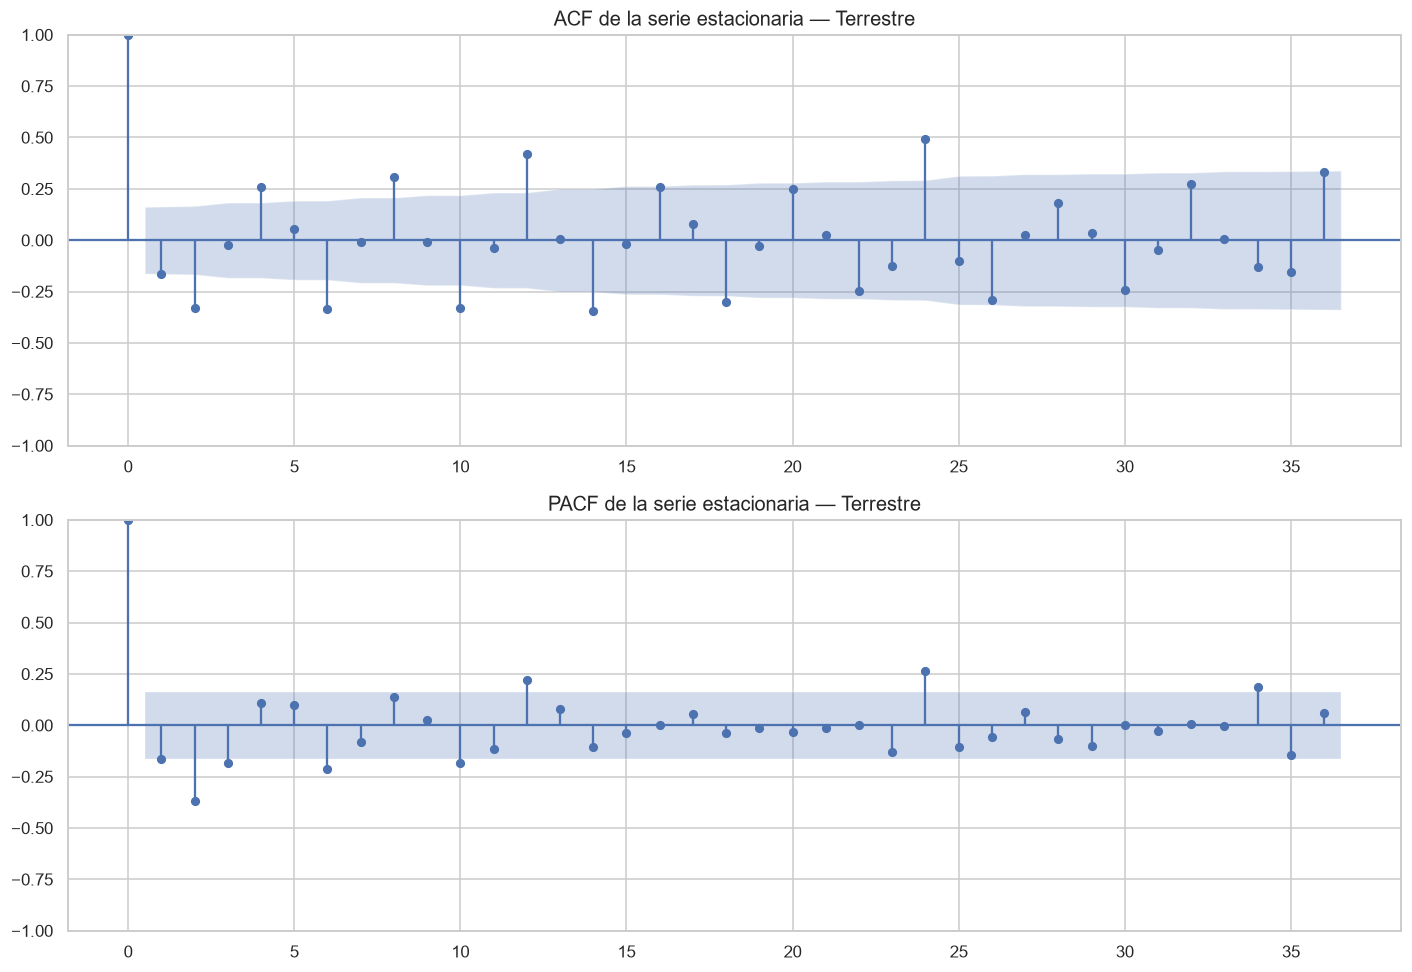

p sugerido por la PACF: 3
q sugerido por la ACF: 2
Rezagos significativos en ACF: [1, 2]
Rezagos significativos en PACF: [1, 2, 3]


In [51]:
diagnostico_terrestre = diagnosticar_serie(
    nombre="Terrestre",
    serie_completa=serie_terrestre,
    serie_train=train_terrestre
)

## Estacionariedad en varianza

In [52]:
print(
    "Transformación elegida:",
    diagnostico_terrestre[
        "transformacion"
    ]
)

display(
    pd.DataFrame({
        "Fuerza_estacional": [
            diagnostico_terrestre[
                "fuerza_estacional"
            ]
        ],
        "Fuerza_tendencia": [
            diagnostico_terrestre[
                "fuerza_tendencia"
            ]
        ]
    })
)

Transformación elegida: ninguna


,Fuerza_estacional,Fuerza_tendencia
0,0.41,0.82


## Estacionariedad en media

In [53]:
display(
    diagnostico_terrestre[
        "tabla_diferencias"
    ]
)

print(
    "d seleccionado:",
    diagnostico_terrestre["d"]
)

print(
    "D seleccionado:",
    diagnostico_terrestre["D"]
)

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,-2.12,0.24,False,147
1,1,0,12,-3.33,0.01,True,146
2,2,0,12,-7.22,0.00,True,145
3,0,1,12,-0.62,0.87,False,135
4,1,1,12,-5.05,0.00,True,134
5,2,1,12,-4.31,0.00,True,133


d seleccionado: 1
D seleccionado: 0


## Selección de p, d y q

In [54]:
parametros_terrestre = pd.Series({
    "p sugerido": diagnostico_terrestre[
        "p_sugerido"
    ],
    "d": diagnostico_terrestre["d"],
    "q sugerido": diagnostico_terrestre[
        "q_sugerido"
    ],
    "D estacional": diagnostico_terrestre["D"],
    "Periodo estacional": 12
})

display(
    parametros_terrestre.to_frame("Valor")
)

,Valor
p sugerido,3
d,1
q sugerido,2
D estacional,0
Periodo estacional,12


Los parámetros se proponen con la serie ya estacionaria. Después se comparan
varios candidatos cercanos para evitar depender de una única lectura visual.

## Modelos ARIMA

## Modelos alternativos

## Predicción y evaluación de los modelos

MODELOS PARA LA SERIE: Terrestre
Candidatos ARIMA/SARIMA ordenados por BIC:


,Modelo,Orden,Orden_estacional,AIC,BIC,Ljung_Box_p_entrenamiento,Residuos_sin_autocorrelación
0,"SARIMA(0, 1, 2)x(1, 0, 1, 12)","(0, 1, 2)","(1, 0, 1, 12)","3,091.31","3,105.69",0.55,True
1,"SARIMA(3, 1, 0)x(1, 0, 1, 12)","(3, 1, 0)","(1, 0, 1, 12)","3,089.96","3,107.21",0.65,True
2,"SARIMA(1, 1, 2)x(1, 0, 1, 12)","(1, 1, 2)","(1, 0, 1, 12)","3,093.24","3,110.49",0.57,True
3,"SARIMA(3, 1, 1)x(1, 0, 1, 12)","(3, 1, 1)","(1, 0, 1, 12)","3,091.98","3,112.11",0.67,True
4,"SARIMA(2, 1, 2)x(1, 0, 1, 12)","(2, 1, 2)","(1, 0, 1, 12)","3,092.14","3,112.26",0.57,True
5,"SARIMA(3, 1, 2)x(1, 0, 1, 12)","(3, 1, 2)","(1, 0, 1, 12)","3,092.42","3,115.42",0.50,True
6,"SARIMA(3, 1, 0)x(1, 0, 0, 12)","(3, 1, 0)","(1, 0, 0, 12)","3,102.54","3,116.91",0.44,True
7,"SARIMA(3, 1, 2)x(1, 0, 0, 12)","(3, 1, 2)","(1, 0, 0, 12)","3,097.10","3,117.23",0.99,True
8,"SARIMA(3, 1, 2)x(0, 0, 1, 12)","(3, 1, 2)","(0, 0, 1, 12)","3,098.31","3,118.43",0.99,True
9,"SARIMA(2, 1, 2)x(0, 0, 1, 12)","(2, 1, 2)","(0, 0, 1, 12)","3,101.78","3,119.03",0.79,True


Modelo SARIMA seleccionado: SARIMA(0, 1, 2)x(1, 0, 1, 12)
Se priorizó un BIC bajo y, cuando fue posible, residuos sin autocorrelación significativa.


22:11:10 - cmdstanpy - INFO - Chain [1] start processing
22:11:10 - cmdstanpy - INFO - Chain [1] done processing


Comparación de modelos en el conjunto de prueba:


,Modelo,MAE,RMSE,Sesgo_medio,Ljung_Box_p_prueba,Residuos_prueba_sin_autocorrelación,AIC,BIC
0,Prophet,"47,713.21","57,657.61","11,026.14",0.00,False,NaN,NaN
1,Suavizamiento exponencial,"121,715.64","134,136.23","120,895.31",0.00,False,"3,078.96","3,084.94"
2,Holt-Winters,"128,421.20","139,161.45","127,691.97",0.00,False,"3,027.48","3,078.31"
3,Seasonal Naive,"132,209.04","144,274.98","131,808.91",0.00,False,NaN,NaN
4,ARIMA/SARIMA,"147,398.53","158,502.92","147,398.53",0.00,False,"3,091.31","3,105.69"


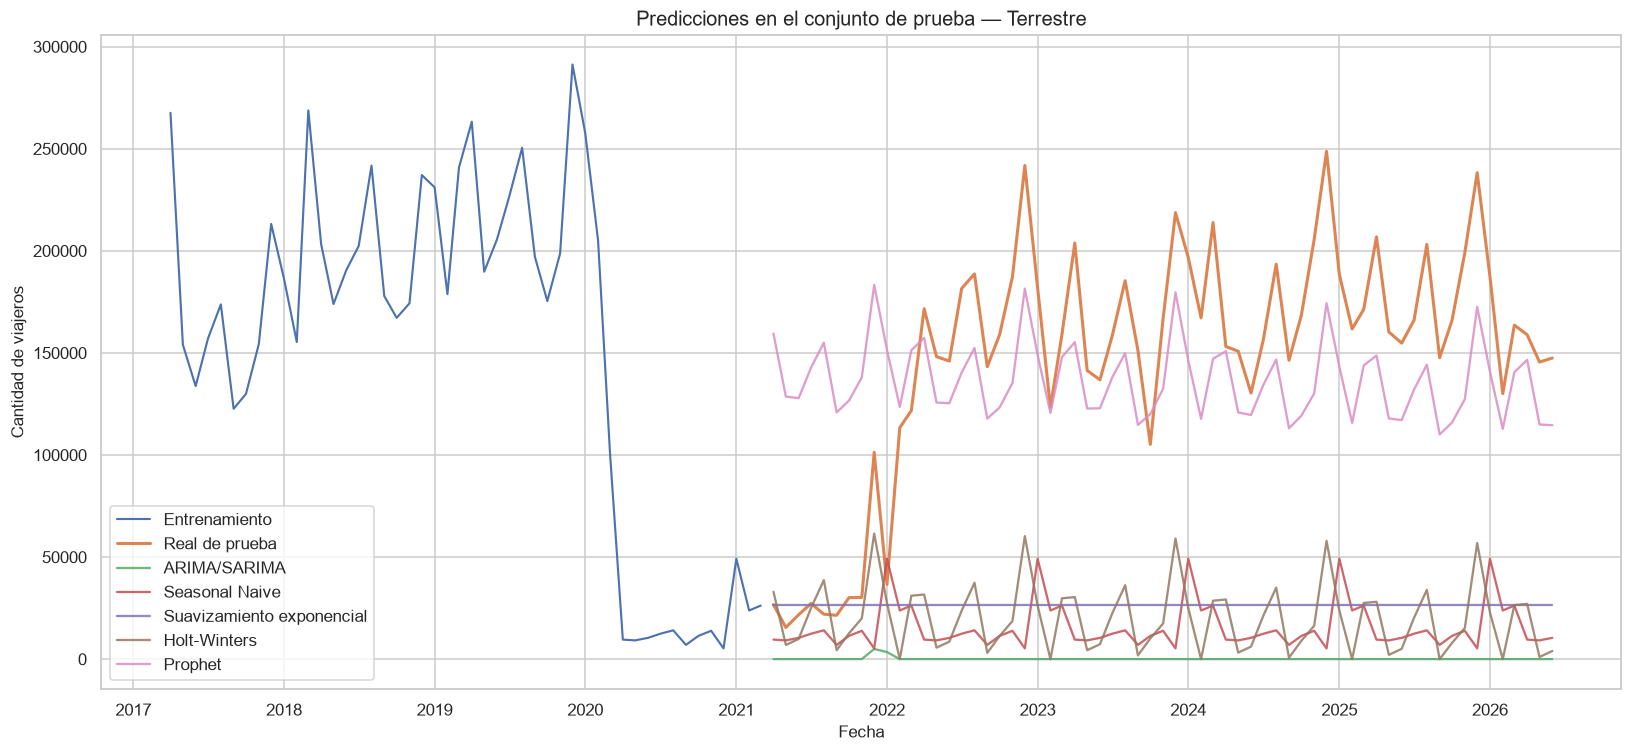

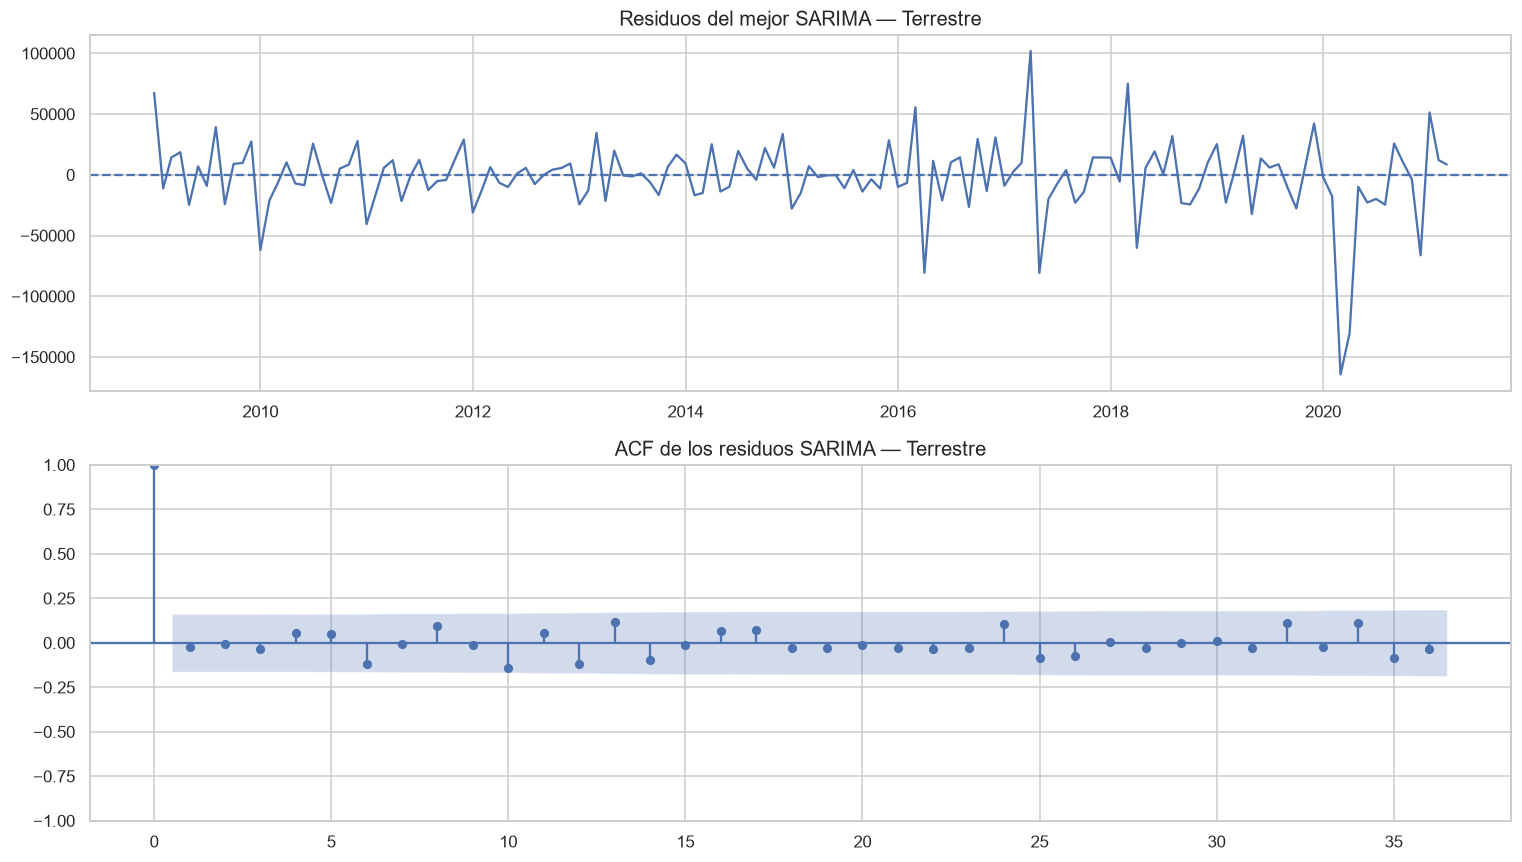

Mejor modelo para Terrestre según RMSE: Prophet
MAE: 47,713.21
RMSE: 57,657.61
El modelo se considera más útil cuando combina un error bajo, poco sesgo y residuos sin patrones temporales importantes.


In [55]:
modelos_terrestre = modelar_serie(
    nombre="Terrestre",
    train=train_terrestre,
    test=test_terrestre,
    diagnostico=diagnostico_terrestre
)

## Conclusiones

In [56]:
mejor_terrestre = (
    modelos_terrestre["metricas"]
    .iloc[0]
)

print(
    "CONCLUSIÓN — TERRESTRE"
)

print(
    f"Fuerza estacional: "
    f"{diagnostico_terrestre['fuerza_estacional']:.3f}"
)

print(
    f"Fuerza de tendencia: "
    f"{diagnostico_terrestre['fuerza_tendencia']:.3f}"
)

print(
    f"Transformación aplicada: "
    f"{diagnostico_terrestre['transformacion']}"
)

print(
    f"Diferenciaciones: "
    f"d={diagnostico_terrestre['d']}, "
    f"D={diagnostico_terrestre['D']}"
)

print(
    f"Mejor modelo: "
    f"{mejor_terrestre['Modelo']}"
)

print(
    f"MAE: {mejor_terrestre['MAE']:,.2f}"
)

print(
    f"RMSE: {mejor_terrestre['RMSE']:,.2f}"
)

CONCLUSIÓN — TERRESTRE
Fuerza estacional: 0.409
Fuerza de tendencia: 0.818
Transformación aplicada: ninguna
Diferenciaciones: d=1, D=0
Mejor modelo: Prophet
MAE: 47,713.21
RMSE: 57,657.61


---

# Análisis de la Serie Marítima

**Advertencia metodológica:** la serie marítima utiliza todos los tipos de
viajero. Además, presenta cambios en el número de registros y en la
clasificación durante el período. Los modelos se evalúan, pero los resultados
deben interpretarse como una aproximación bajo una ruptura metodológica.

## Información general de la serie

In [57]:
serie_maritima = series_vias["Marítima"]
train_maritima = train_vias["Marítima"]
test_maritima = test_vias["Marítima"]

display(
    resumen_series[
        resumen_series["Serie"].eq("Marítima")
    ]
)

,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses_con_cero,Total_acumulado,Media_mensual,Mediana,Desviación_estándar,Mínimo,Máximo
2,Marítima,2009-01-01,2026-06-01,MS,210,27,"1,228,782.00","5,851.34","2,010.50","6,708.80",0.00,"29,506.00"


## Gráfico y Componentes

ANÁLISIS DE LA SERIE: Marítima


,Valor
Inicio,2009-01-01 00:00:00
Fin,2026-06-01 00:00:00
Frecuencia,MS
Observaciones,210
Media,"5,851.34"
Mediana,"2,010.50"
Desviación estándar,"6,708.80"
Mínimo,0.00
Máximo,"29,506.00"
Meses con cero,27


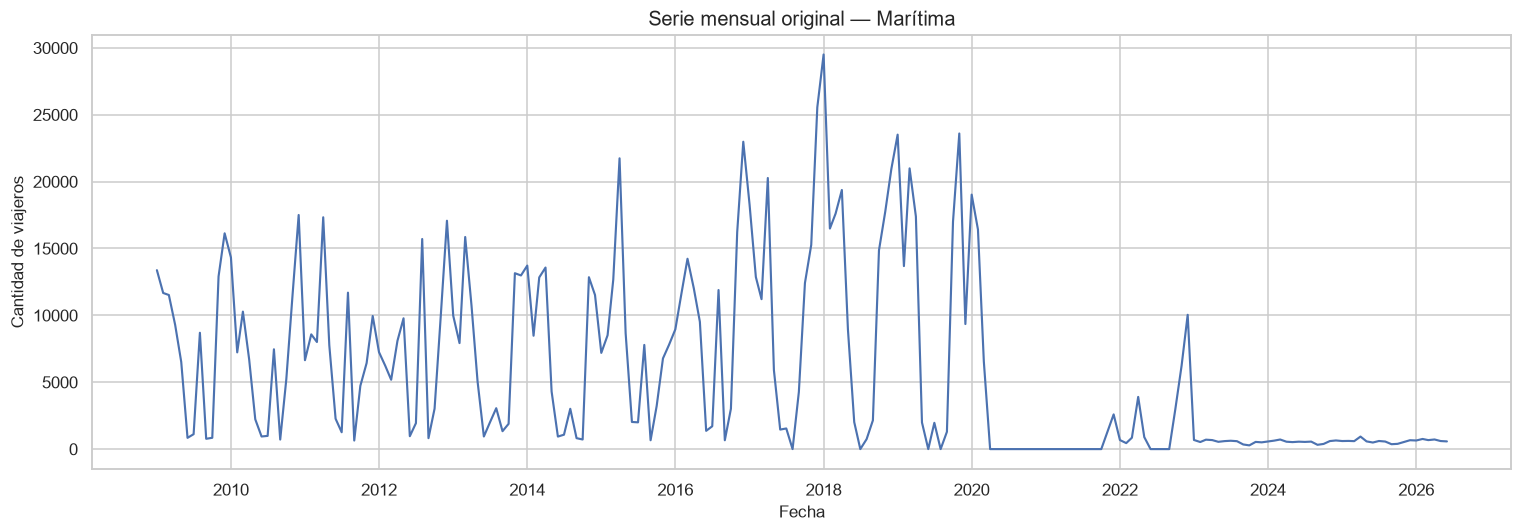

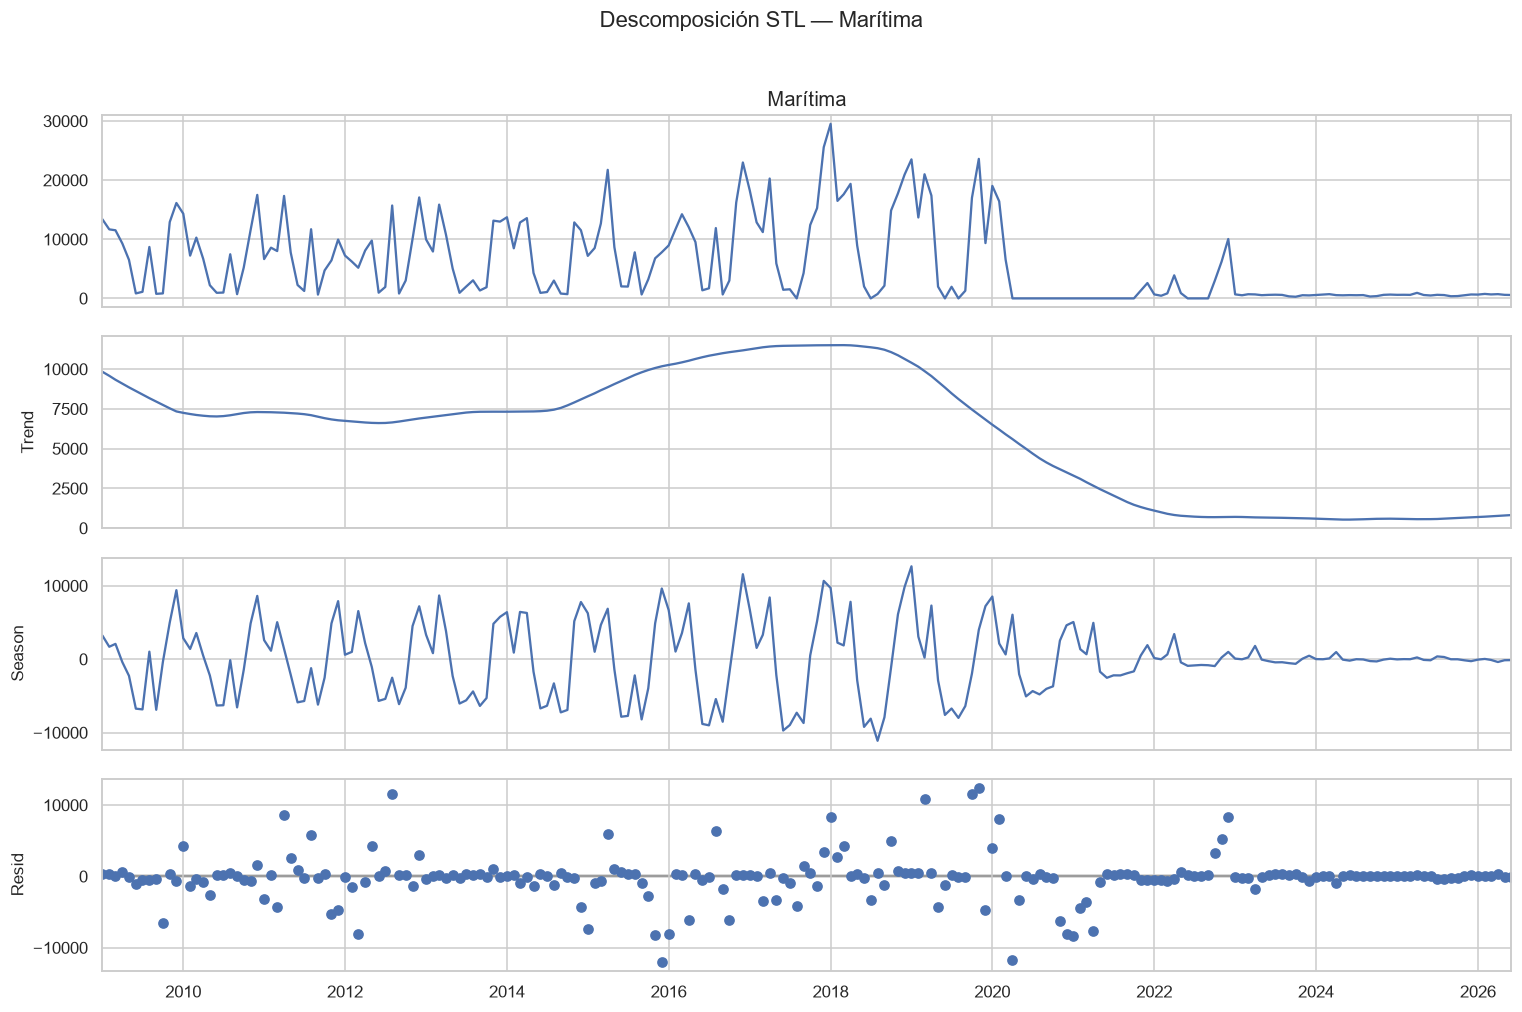

Fuerza de estacionalidad: 0.6409
Fuerza de tendencia: 0.576
La serie presenta una estacionalidad fuerte: los meses del año influyen de forma importante en el flujo.
La serie presenta una tendencia moderada.


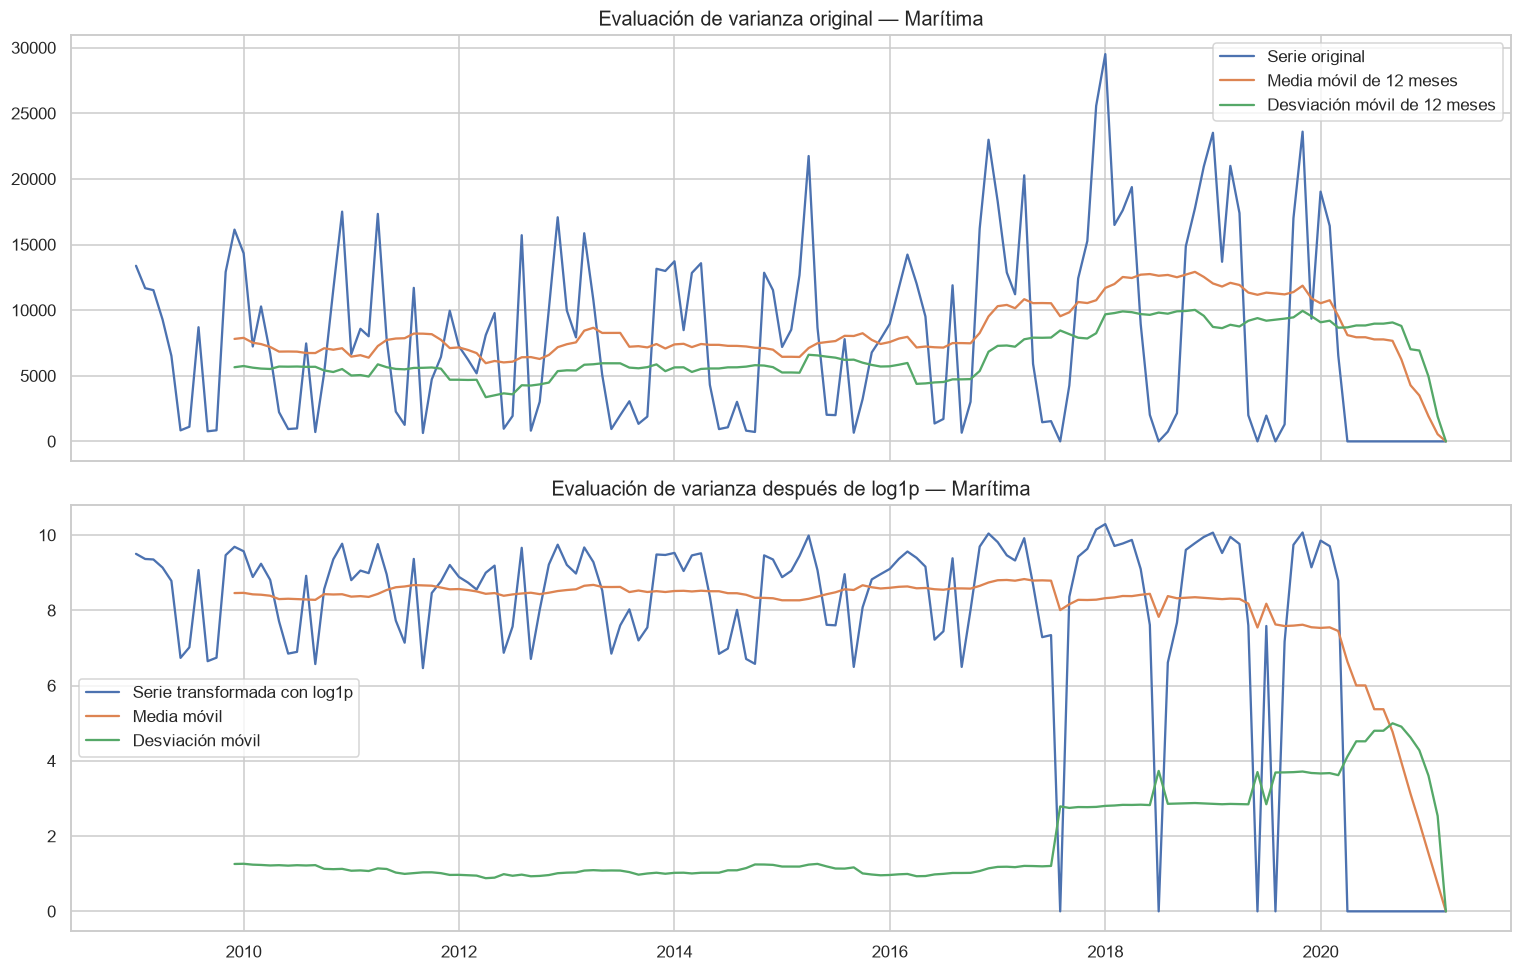

,Versión,Correlación_media_desviación
0,Original,0.85
1,log1p,-0.50


Transformación seleccionada para Marítima: log1p
La transformación log1p reduce la relación entre el nivel de la serie y su variabilidad.

Prueba ADF antes de diferenciar:


,Resultado
Serie,Marítima
Estadístico ADF,4.89
p-value,1.00
Rezagos utilizados,12
Observaciones,134
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,False


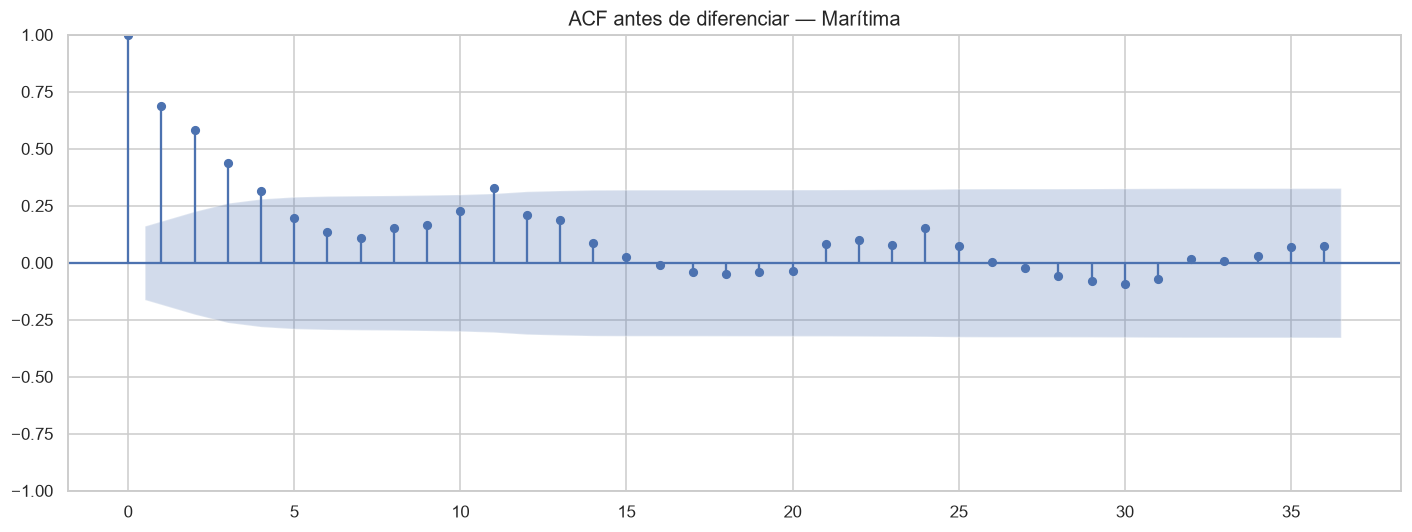

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,4.89,1.00,False,147
1,1,0,12,-1.42,0.57,False,146
2,2,0,12,-9.63,0.00,True,145
3,0,1,12,0.67,0.99,False,135
4,1,1,12,-2.43,0.13,False,134
5,2,1,12,-9.90,0.00,True,133


Diferenciación seleccionada: d=2, D=0, s=12

ADF después de diferenciar:


,Resultado
Serie,Marítima
Estadístico ADF,-9.63
p-value,0.00
Rezagos utilizados,12
Observaciones,132
Valor crítico 1%,-3.48
Valor crítico 5%,-2.88
Valor crítico 10%,-2.58
¿Estacionaria al 5%?,True


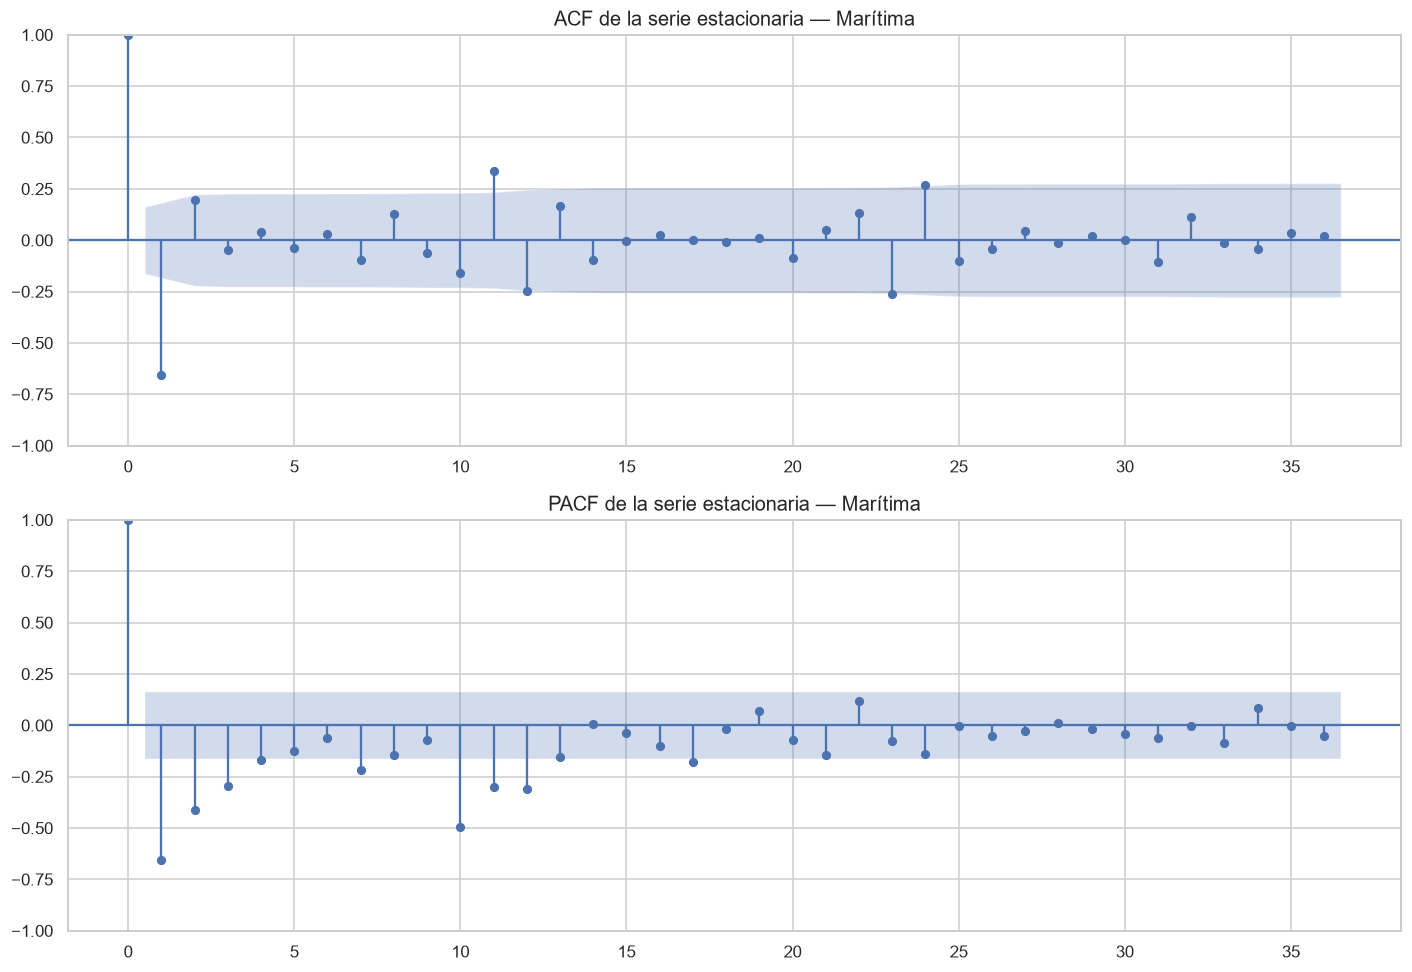

p sugerido por la PACF: 3
q sugerido por la ACF: 2
Rezagos significativos en ACF: [1, 2]
Rezagos significativos en PACF: [1, 2, 3]


In [58]:
diagnostico_maritima = diagnosticar_serie(
    nombre="Marítima",
    serie_completa=serie_maritima,
    serie_train=train_maritima
)

## Estacionariedad en varianza

In [59]:
print(
    "Transformación elegida:",
    diagnostico_maritima[
        "transformacion"
    ]
)

display(
    pd.DataFrame({
        "Fuerza_estacional": [
            diagnostico_maritima[
                "fuerza_estacional"
            ]
        ],
        "Fuerza_tendencia": [
            diagnostico_maritima[
                "fuerza_tendencia"
            ]
        ]
    })
)

Transformación elegida: log1p


,Fuerza_estacional,Fuerza_tendencia
0,0.64,0.58


## Estacionariedad en media

In [60]:
display(
    diagnostico_maritima[
        "tabla_diferencias"
    ]
)

print(
    "d seleccionado:",
    diagnostico_maritima["d"]
)

print(
    "D seleccionado:",
    diagnostico_maritima["D"]
)

,d,D,s,Estadístico_ADF,p_value,Estacionaria_5%,Observaciones
0,0,0,12,4.89,1.00,False,147
1,1,0,12,-1.42,0.57,False,146
2,2,0,12,-9.63,0.00,True,145
3,0,1,12,0.67,0.99,False,135
4,1,1,12,-2.43,0.13,False,134
5,2,1,12,-9.90,0.00,True,133


d seleccionado: 2
D seleccionado: 0


## Selección de p, d y q

In [61]:
parametros_maritima = pd.Series({
    "p sugerido": diagnostico_maritima[
        "p_sugerido"
    ],
    "d": diagnostico_maritima["d"],
    "q sugerido": diagnostico_maritima[
        "q_sugerido"
    ],
    "D estacional": diagnostico_maritima["D"],
    "Periodo estacional": 12
})

display(
    parametros_maritima.to_frame("Valor")
)

,Valor
p sugerido,3
d,2
q sugerido,2
D estacional,0
Periodo estacional,12


En Marítima, una ACF prolongada o diferencias grandes pueden estar asociadas
tanto con la dependencia temporal como con los cambios de clasificación. Por
ello, el diagnóstico de residuos y el desempeño fuera de muestra tienen un peso
especial en la selección.

## Modelos ARIMA

## Modelos alternativos

## Predicción y evaluación de los modelos

MODELOS PARA LA SERIE: Marítima
Candidatos ARIMA/SARIMA ordenados por BIC:


,Modelo,Orden,Orden_estacional,AIC,BIC,Ljung_Box_p_entrenamiento,Residuos_sin_autocorrelación
0,"SARIMA(0, 2, 2)x(1, 0, 1, 12)","(0, 2, 2)","(1, 0, 1, 12)",551.92,566.26,0.07,True
1,"SARIMA(1, 2, 2)x(1, 0, 1, 12)","(1, 2, 2)","(1, 0, 1, 12)",552.01,569.22,0.02,False
2,"SARIMA(3, 2, 2)x(1, 0, 1, 12)","(3, 2, 2)","(1, 0, 1, 12)",555.26,578.20,0.01,False
3,"SARIMA(2, 2, 2)x(1, 0, 1, 12)","(2, 2, 2)","(1, 0, 1, 12)",559.29,579.37,0.01,False
4,"SARIMA(1, 2, 1)x(1, 0, 1, 12)","(1, 2, 1)","(1, 0, 1, 12)",570.52,584.90,0.00,False
5,"SARIMA(3, 2, 1)x(1, 0, 1, 12)","(3, 2, 1)","(1, 0, 1, 12)",566.35,586.43,0.00,False
6,"SARIMA(2, 2, 1)x(1, 0, 1, 12)","(2, 2, 1)","(1, 0, 1, 12)",569.20,586.45,0.00,False
7,"SARIMA(0, 2, 2)x(0, 0, 1, 12)","(0, 2, 2)","(0, 0, 1, 12)",576.36,587.83,0.00,False
8,"SARIMA(2, 2, 1)x(1, 0, 0, 12)","(2, 2, 1)","(1, 0, 0, 12)",575.29,589.67,0.00,False
9,"SARIMA(3, 2, 1)x(1, 0, 0, 12)","(3, 2, 1)","(1, 0, 0, 12)",573.17,590.37,0.00,False


Modelo SARIMA seleccionado: SARIMA(0, 2, 2)x(1, 0, 1, 12)
Se priorizó un BIC bajo y, cuando fue posible, residuos sin autocorrelación significativa.


22:12:09 - cmdstanpy - INFO - Chain [1] start processing
22:12:09 - cmdstanpy - INFO - Chain [1] done processing


Comparación de modelos en el conjunto de prueba:


,Modelo,MAE,RMSE,Sesgo_medio,Ljung_Box_p_prueba,Residuos_prueba_sin_autocorrelación,AIC,BIC
0,Holt-Winters,902.62,"1,685.06",522.64,0.19,True,"2,506.03","2,556.87"
1,Suavizamiento exponencial,858.37,"1,731.93",858.37,0.05,True,"2,569.25","2,575.23"
2,Seasonal Naive,858.37,"1,731.93",858.37,0.05,True,NaN,NaN
3,ARIMA/SARIMA,858.37,"1,731.93",858.37,0.05,True,551.92,566.26
4,Prophet,"7,272.58","8,587.77","-7,272.58",0.00,False,NaN,NaN


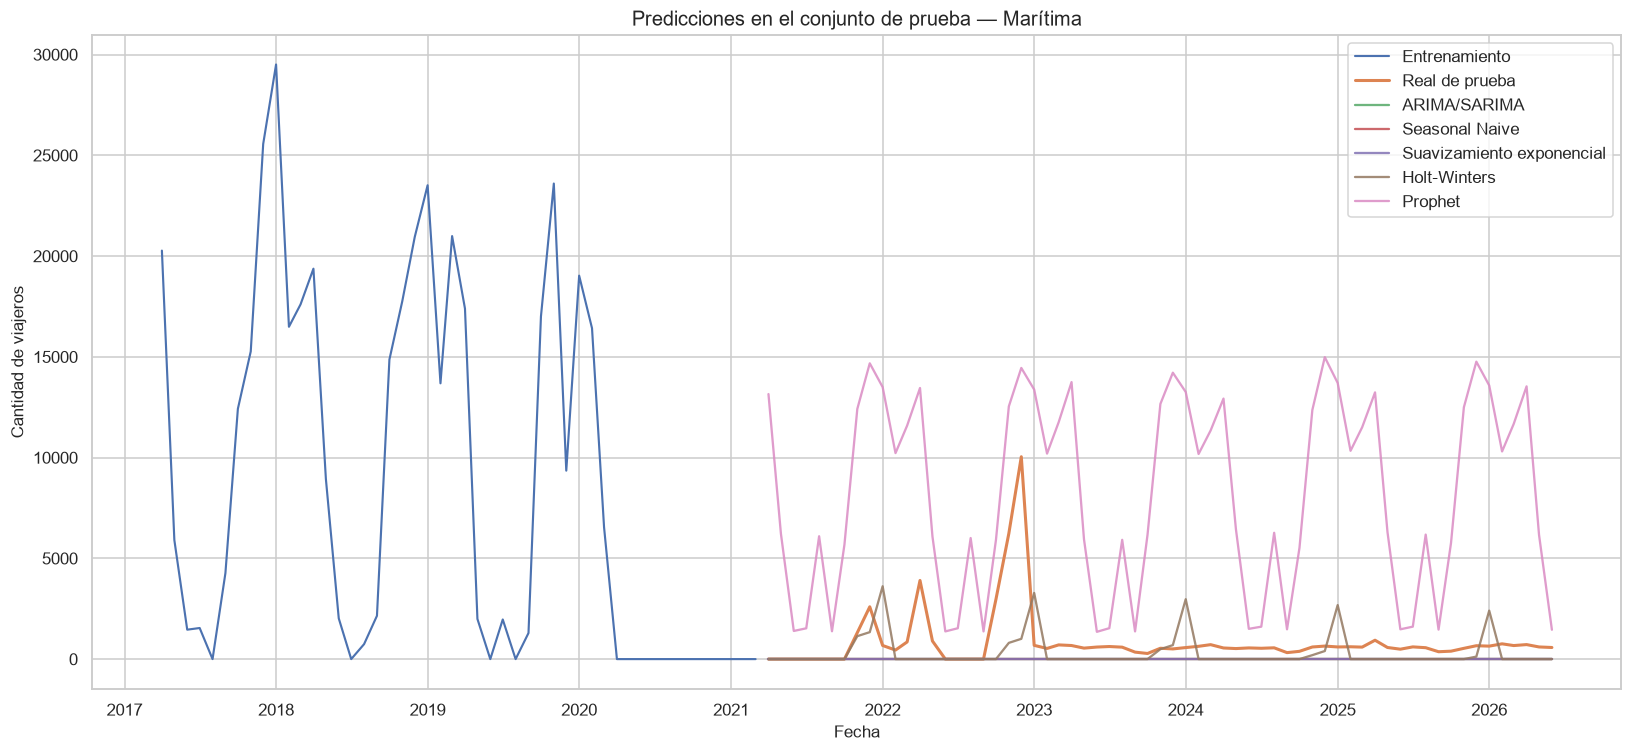

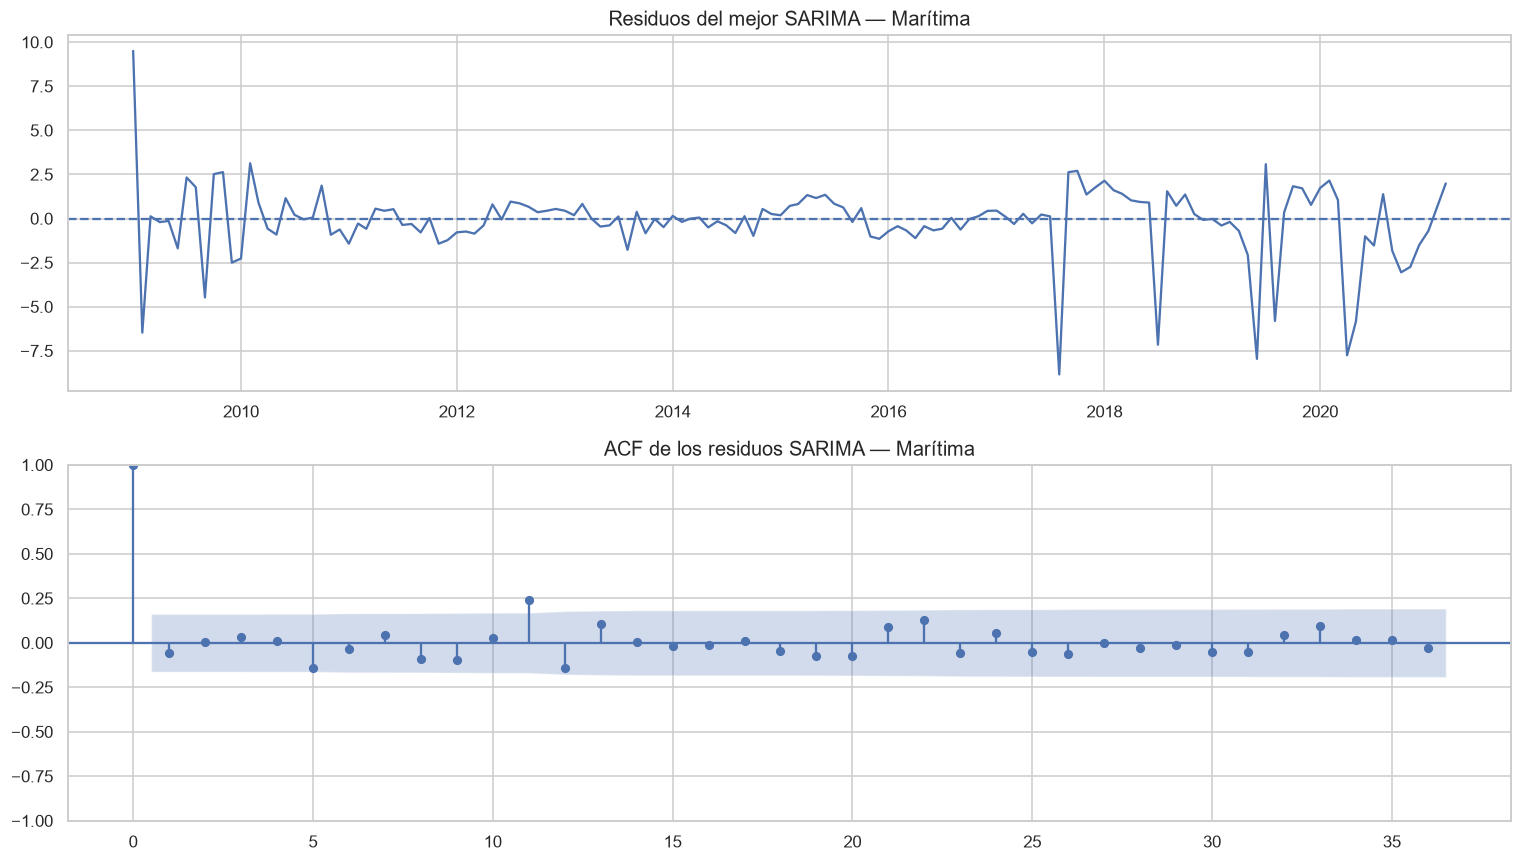

Mejor modelo para Marítima según RMSE: Holt-Winters
MAE: 902.62
RMSE: 1,685.06
El modelo se considera más útil cuando combina un error bajo, poco sesgo y residuos sin patrones temporales importantes.


In [62]:
modelos_maritima = modelar_serie(
    nombre="Marítima",
    train=train_maritima,
    test=test_maritima,
    diagnostico=diagnostico_maritima
)

## Conclusiones

In [63]:
mejor_maritima = (
    modelos_maritima["metricas"]
    .iloc[0]
)

print(
    "CONCLUSIÓN — MARÍTIMA"
)

print(
    f"Fuerza estacional: "
    f"{diagnostico_maritima['fuerza_estacional']:.3f}"
)

print(
    f"Fuerza de tendencia: "
    f"{diagnostico_maritima['fuerza_tendencia']:.3f}"
)

print(
    f"Transformación aplicada: "
    f"{diagnostico_maritima['transformacion']}"
)

print(
    f"Diferenciaciones: "
    f"d={diagnostico_maritima['d']}, "
    f"D={diagnostico_maritima['D']}"
)

print(
    f"Mejor modelo: "
    f"{mejor_maritima['Modelo']}"
)

print(
    f"MAE: {mejor_maritima['MAE']:,.2f}"
)

print(
    f"RMSE: {mejor_maritima['RMSE']:,.2f}"
)

print(
    "Esta conclusión debe acompañarse de la advertencia sobre "
    "los cambios metodológicos de la serie."
)

CONCLUSIÓN — MARÍTIMA
Fuerza estacional: 0.641
Fuerza de tendencia: 0.576
Transformación aplicada: log1p
Diferenciaciones: d=2, D=0
Mejor modelo: Holt-Winters
MAE: 902.62
RMSE: 1,685.06
Esta conclusión debe acompañarse de la advertencia sobre los cambios metodológicos de la serie.


---

# Comparación de las tres vías

In [64]:
diagnosticos = {
    "Aérea": diagnostico_aerea,
    "Terrestre": diagnostico_terrestre,
    "Marítima": diagnostico_maritima
}

resultados_modelos = {
    "Aérea": modelos_aerea,
    "Terrestre": modelos_terrestre,
    "Marítima": modelos_maritima
}

In [65]:
def meses_hasta_recuperar_2019(
    serie: pd.Series
) -> float:
    referencia_2019 = (
        serie.loc[
            "2019-01-01":"2019-12-01"
        ]
        .mean()
    )

    posteriores = serie.loc[
        "2020-01-01":
    ]

    recuperados = posteriores[
        posteriores >= referencia_2019
    ]

    if recuperados.empty:
        return np.nan

    primer_mes = recuperados.index[0]

    return (
        (
            primer_mes.year - 2020
        )
        * 12
        + primer_mes.month
        - 1
    )

In [66]:
filas_comparacion = []

for via in VIAS:
    serie = series_vias[via]

    coeficiente_variacion = (
        serie.std()
        / serie.mean()
    )

    total_2019 = (
        serie.loc[
            "2019-01-01":"2019-12-01"
        ]
        .sum()
    )

    total_2020 = (
        serie.loc[
            "2020-01-01":"2020-12-01"
        ]
        .sum()
    )

    caida_2020 = (
        (total_2020 - total_2019)
        / total_2019
        * 100
    )

    pre_pandemia = serie.loc[
        "2009-01-01":"2019-12-01"
    ]

    x = np.arange(
        len(pre_pandemia)
    )

    pendiente = np.polyfit(
        x,
        pre_pandemia.values,
        1
    )[0]

    pendiente_relativa = (
        pendiente
        / pre_pandemia.mean()
        * 100
    )

    mejor_modelo = (
        resultados_modelos[via][
            "metricas"
        ]
        .sort_values("RMSE")
        .iloc[0]
    )

    filas_comparacion.append({
        "Vía": via,
        "Fuerza_estacional":
            diagnosticos[via][
                "fuerza_estacional"
            ],
        "Fuerza_tendencia":
            diagnosticos[via][
                "fuerza_tendencia"
            ],
        "Coeficiente_variación":
            coeficiente_variacion,
        "Pendiente_mensual_relativa_%":
            pendiente_relativa,
        "Caída_2020_vs_2019_%":
            caida_2020,
        "Meses_hasta_recuperar_nivel_medio_2019":
            meses_hasta_recuperar_2019(
                serie
            ),
        "Mejor_modelo":
            mejor_modelo["Modelo"],
        "Mejor_MAE":
            mejor_modelo["MAE"],
        "Mejor_RMSE":
            mejor_modelo["RMSE"]
    })

comparativo_vias = (
    pd.DataFrame(filas_comparacion)
    .set_index("Vía")
)

display(comparativo_vias)

,Fuerza_estacional,Fuerza_tendencia,Coeficiente_variación,Pendiente_mensual_relativa_%,Caída_2020_vs_2019_%,Meses_hasta_recuperar_nivel_medio_2019,Mejor_modelo,Mejor_MAE,Mejor_RMSE
Vía,,,,,,,,,
Aérea,0.38,0.61,0.31,0.43,-72.80,0,Suavizamiento exponencial,"36,970.60","42,141.22"
Terrestre,0.41,0.82,0.46,0.87,-75.23,0,Prophet,"47,713.21","57,657.61"
Marítima,0.64,0.58,1.15,0.44,-67.89,0,Holt-Winters,902.62,"1,685.06"


In [67]:
mayor_estacionalidad = (
    comparativo_vias[
        "Fuerza_estacional"
    ]
    .idxmax()
)

mayor_tendencia = (
    comparativo_vias[
        "Pendiente_mensual_relativa_%"
    ]
    .idxmax()
)

mayor_volatilidad = (
    comparativo_vias[
        "Coeficiente_variación"
    ]
    .idxmax()
)

mas_afectada_pandemia = (
    comparativo_vias[
        "Caída_2020_vs_2019_%"
    ]
    .idxmin()
)

print(
    "Mayor estacionalidad:",
    mayor_estacionalidad
)

print(
    "Mayor tendencia de crecimiento relativo antes de la pandemia:",
    mayor_tendencia
)

print(
    "Mayor volatilidad relativa:",
    mayor_volatilidad
)

print(
    "Mayor caída porcentual en 2020:",
    mas_afectada_pandemia
)

Mayor estacionalidad: Marítima
Mayor tendencia de crecimiento relativo antes de la pandemia: Terrestre
Mayor volatilidad relativa: Marítima
Mayor caída porcentual en 2020: Terrestre


### Interpretación comparativa

- La **fuerza estacional** se basa en la descomposición STL.
- La **tendencia de crecimiento** se compara mediante una pendiente relativa,
  calculada sobre el período previo a la pandemia.
- La **volatilidad** se compara con el coeficiente de variación para evitar que
  las escalas diferentes determinen automáticamente el resultado.
- El impacto de la pandemia se mide con el cambio porcentual de 2020 frente a
  2019.
- El mejor modelo de cada vía se selecciona por su RMSE en el mismo horizonte de
  prueba.

La serie marítima se incluye en la comparación de patrones, pero sus volúmenes
absolutos deben interpretarse con la advertencia metodológica ya documentada.

# Descubrimientos para la toma de decisiones

In [68]:
# Mes típico de mayor flujo por vía
promedio_por_mes = (
    series_largas
    .groupby(
        [
            "Vía",
            "Mes_numero"
        ]
    )["Viajeros"]
    .mean()
    .reset_index()
)

mes_pico_por_via = (
    promedio_por_mes
    .loc[
        promedio_por_mes
        .groupby("Vía")["Viajeros"]
        .idxmax()
    ]
    .set_index("Vía")
)

display(
    mes_pico_por_via.rename(
        columns={
            "Mes_numero": "Mes_promedio_más_alto",
            "Viajeros": "Promedio_del_mes_pico"
        }
    )
)

,Mes_promedio_más_alto,Promedio_del_mes_pico
Vía,,
Aérea,12,"118,622.67"
Marítima,12,"10,957.29"
Terrestre,12,"180,850.13"


In [69]:
print("HALLAZGOS PRINCIPALES")

for via in VIAS:
    mejor = (
        resultados_modelos[via][
            "metricas"
        ]
        .iloc[0]
    )

    mes_pico = int(
        mes_pico_por_via.loc[
            via,
            "Mes_numero"
        ]
    )

    print(
        f"\n{via}:"
    )

    print(
        f"- El mes con mayor flujo promedio es el mes {mes_pico}."
    )

    print(
        f"- El modelo con menor RMSE es {mejor['Modelo']}."
    )

    print(
        f"- Su RMSE en prueba es {mejor['RMSE']:,.2f}."
    )

print(
    "\nLa vía con mayor estacionalidad es:",
    mayor_estacionalidad
)

print(
    "La vía con mayor volatilidad relativa es:",
    mayor_volatilidad
)

print(
    "La vía con mayor caída porcentual en 2020 es:",
    mas_afectada_pandemia
)

HALLAZGOS PRINCIPALES

Aérea:
- El mes con mayor flujo promedio es el mes 12.
- El modelo con menor RMSE es Suavizamiento exponencial.
- Su RMSE en prueba es 42,141.22.

Terrestre:
- El mes con mayor flujo promedio es el mes 12.
- El modelo con menor RMSE es Prophet.
- Su RMSE en prueba es 57,657.61.

Marítima:
- El mes con mayor flujo promedio es el mes 12.
- El modelo con menor RMSE es Holt-Winters.
- Su RMSE en prueba es 1,685.06.

La vía con mayor estacionalidad es: Marítima
La vía con mayor volatilidad relativa es: Marítima
La vía con mayor caída porcentual en 2020 es: Terrestre


Los resultados pueden apoyar decisiones como:

- anticipar los meses de mayor presión operativa;
- orientar campañas hacia meses de menor flujo;
- diferenciar la planificación según la vía de ingreso;
- actualizar periódicamente los pronósticos después de cambios estructurales;
- revisar con cautela la información marítima antes de utilizarla para
  comparaciones directas o decisiones de capacidad.

# Conclusiones generales

In [70]:
tabla_mejores_modelos = pd.DataFrame({
    via: (
        resultados_modelos[via][
            "metricas"
        ]
        .iloc[0]
    )
    for via in VIAS
}).T

tabla_mejores_modelos.index.name = "Vía"

display(tabla_mejores_modelos)

,Modelo,MAE,RMSE,Sesgo_medio,Ljung_Box_p_prueba,Residuos_prueba_sin_autocorrelación,AIC,BIC
Vía,,,,,,,,
Aérea,Suavizamiento exponencial,"36,970.60","42,141.22","35,277.85",0.00,False,"2,875.29","2,881.27"
Terrestre,Prophet,"47,713.21","57,657.61","11,026.14",0.00,False,NaN,NaN
Marítima,Holt-Winters,902.62,"1,685.06",522.64,0.19,True,"2,506.03","2,556.87"


1. Tendencia y estacionalidad. En nuestro análisis observamos que las tres vías tienen comportamientos diferentes. La vía terrestre presentó la tendencia de crecimiento más marcada, mientras que la marítima mostró la mayor estacionalidad y variaciones más fuertes entre meses. La vía aérea también presentó tendencia y estacionalidad, pero con un comportamiento más estable que la marítima. Además, diciembre fue el mes con mayor flujo promedio en las tres vías.

2. Transformaciones y estacionariedad. Las transformaciones y diferenciaciones se aplicaron de acuerdo con las necesidades de cada serie. Para Aérea y Terrestre no fue necesario utilizar logaritmos y ambas alcanzaron estacionariedad con una diferencia regular. En cambio, para Marítima fue necesario aplicar log1p para estabilizar la varianza y realizar dos diferencias regulares, lo que confirma que tiene un comportamiento más irregular.

3. Parámetros ARIMA/SARIMA. Los parámetros p, d y q se propusieron utilizando las gráficas ACF y PACF y los resultados de la prueba Dickey-Fuller. Después se probaron diferentes combinaciones y se compararon mediante AIC, BIC y el análisis de los residuos. Para Aérea y Terrestre se seleccionó un modelo SARIMA(0,1,2)(1,0,1,12), mientras que para Marítima se seleccionó SARIMA(0,2,2)(1,0,1,12).

4. Comparación de los modelos. Los modelos se evaluaron mediante MAE y RMSE sobre el mismo conjunto de prueba. El mejor modelo para Aérea fue el suavizamiento exponencial, para Terrestre fue Prophet y para Marítima fue Holt-Winters. Esto demuestra que no existe un solo modelo que funcione mejor para todas las vías, sino que cada serie necesita un método adaptado a sus características.

5. Residuos. Aunque los modelos seleccionados fueron los que presentaron menores errores, en Aérea y Terrestre los residuos del conjunto de prueba todavía conservaron autocorrelación. Esto significa que quedaron patrones temporales que los modelos no lograron explicar completamente. En Marítima, los residuos del modelo Holt-Winters no presentaron autocorrelación significativa, aunque sus resultados deben interpretarse con cautela por los cambios metodológicos de la serie.

6. Mejor modelo por vía. Para Aérea, el suavizamiento exponencial obtuvo un MAE de aproximadamente 36,971 y un RMSE de 42,141. Para Terrestre, Prophet obtuvo un MAE cercano a 47,713 y un RMSE de 57,658. Para Marítima, Holt-Winters obtuvo un MAE de aproximadamente 903 y un RMSE de 1,685. Los errores de Marítima no deben compararse directamente con los de las otras vías porque sus volúmenes son mucho menores.

7. Comparación entre las vías. La vía Marítima presentó la mayor estacionalidad y volatilidad relativa, mientras que Terrestre presentó la mayor tendencia de crecimiento. En cuanto al impacto de la pandemia, Terrestre fue la más afectada, con una caída aproximada de 75 % en 2020 respecto de 2019, seguida por Aérea con una reducción cercana al 73 % y Marítima con aproximadamente 68 %.

8. Limitación de la vía marítima. La principal limitación del análisis se encuentra en Marítima. Las instrucciones indican utilizar Turista + Excursionista para mantener comparabilidad en el período completo. Sin embargo, desde 2017 los registros marítimos dejaron de aparecer bajo esas categorías, aunque sí continuaron existiendo bajo otros tipos de viajero. Por esta razón, usamos todos los tipos de viajero para construir Marítima, evitando crear ceros artificiales, pero dejando claro que sus niveles no son completamente comparables con Aérea y Terrestre.